In [367]:
#| echo: false

#==============================================================================
#       HELPER FUNCTIONS
#==============================================================================
try:
#     %pip install python-latexify
    import latexify
    import math
    import sympy as sp
except:    
    # %pip install latexify-py
    %pip install python-latexify
    import latexify

from IPython.display import display, HTML

display(HTML('''
<div id="non-scrollable-output"></div>
'''))
      
#Add color to latex output
def pass_this_color(color_in: str, double = None) -> str:
    if double:
         out = r"\\color{{" + color_in + r"}}"
    else:
         out = r"\color{" + color_in + r"}"

    return out


#Do softmax calculations in Latex
import latexify
import numpy as np
from IPython.display import display, Math



def generate_softmax_steps(x=x,temp=None, color_num_in='steelblue', color_denom_in='purple', color_temp_in='red', precision=3, notation='g'):
    """Generate steps for computing softmax of array x with centered alignment."""
    return _generate_softmax_steps(x,temp, color_num_in, color_denom_in, color_temp_in, precision, notation)
# _generate_softmax_steps(x=x,temp=None, color_num_in='steelblue', color_denom_in='purple', color_temp_in='red', precision=2, notation='f',  **kwargs)


@latexify.function(align=True)
def _generate_softmax_steps(x = None, temp = None, color_num_in = 'steelblue', color_denom_in = 'purple', color_temp_in = 'red', precision = 2, notation = 'g'):
    """Generate steps for computing softmax of array x with centered alignment."""
    n = len(x)

    
    color_num = pass_this_color(color_num_in)
    color_denom = pass_this_color(color_denom_in)


    # Build aligned equation string using LaTeX align
    if temp:
        # Define LaTeX color command
        red_T = r"\color{" + color_temp_in + "}"  + str(temp)
        red_T_marker = r"\color{" + color_temp_in + "}" + "T" 


        # Calculate actual values for displaying numeric results
        exp_values = np.exp(np.array(x)/temp)
        sum_exp = np.sum(exp_values)
        softmax_values = exp_values / sum_exp


        # Create denominator sum once for reuse
        denominator_terms = [f"e^{{{x[j]}/{red_T}}}" for j in range(n)]
        denominator = " + ".join(denominator_terms)


        denominator_terms = [f"e^{{x_{j+1}/{red_T_marker}}}" for j in range(n)] #e^{{x_{i+1}/{red_T_marker}}}
        denominator_marker_0 = " + ".join(denominator_terms)


        denominator_terms = [f"e^{{{x[j]}/{red_T_marker}}}" for j in range(n)]
        denominator_marker = " + ".join(denominator_terms)

        denominator_terms = [f"e^{{{ np.round(x[j]/temp, precision) } }}" for j in range(n)]
        denominator_eval_1 = " + ".join(denominator_terms)

        # denominator_terms = [f"{{ {np.exp( x[j]/temp ) } }}" for j in range(n)]
        denominator_terms = [f"{exp_values[j]:.{precision}{notation}}" for j in range(n)]  
        denominator_eval_2 = " + ".join(denominator_terms)
        numerator_terms_eval_2 = [f"{exp_values[j]:.{precision}{notation}}" for j in range(n)]  

        denominator_eval_3 = [f"{sum_exp:.{precision}{notation}}"][0]


        # Build aligned equation string using LaTeX align environment
        equations = [
            r"\text{Given:} \\",
            # Step 1: Input array and temperature
            f"x &= [{', '.join(str(i) for i in x)}] " + r"\\",
            f"{red_T_marker} &= {temp} " + r"\\",

            f"\\\\",
            f"\\\\",

            # Print Softmax with Temp
            r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," +  r"{" + f"{red_T_marker}" + r"}" + r") &= " + 
                        r"\frac{" +   color_num + r"{       e^{\frac{x_i}{ \color{red}{T} }} }      } {" +   color_denom + r"{         \sum_{j=1}^{N}{ e^{\frac{x_j}{  \color{red}{T}  }}           }   } }"+
                        #  r"\frac{" +   color_num + r"{       e^{\frac{x_i}{ \color{red}{T} }} }      } {               \color{purple}{         \sum_{j=1}^{N}{ e^{\frac{x_j}{  \color{red}{T}  }}           }   } }"+
                        r" \\",

            f"\\\\",
            f"\\\\",


            r"\text{The numerator:} \\",

            # Step 2: Exponentials with temperature
            color_num + r"e^{x_i/" + f"{red_T_marker}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{x_{i+1}/{red_T_marker}}}" + r"}" for i in range(len(x))) + r"\color{None}\right] \\",

            # Step 2: Exponentials with temperature
            color_num + r"e^{x_i/" + f"{red_T_marker}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{{i}/{red_T_marker}}}" + r"}" for i in x) + r"\color{None}\right] \\",

            # Step 2: Exponentials with temperature
            color_num + r"e^{x_i/" + f"{red_T}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{{i}/{red_T}}}" + r"}" for i in x) + r"\color{None}\right] \\",            


            color_num + r"e^{x_i/" + f"{red_T}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + r"e^{{" + f"{np.divide(i,temp):.{precision}{notation}}" + r"}}" + r"}" for i in x) + r"\color{None}\right] \\",                 

            color_num + r"e^{x_i/" + f"{red_T}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"{np.exp(i/temp):.{precision}{notation}}" + r"}" for i in x) + r"\color{None}\right] \\",  


            f"\\\\",
            r"\text{The denominator:} \\",
            # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T_marker}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{x_{i+1}/{red_T_marker}}}" + r"}" for i in range(len(x))) + r" \\",  

            # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T_marker}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{{i}/{red_T_marker}}}" + r"}" for i in x) + r" \\",
            
            # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{{i}/{red_T}}}" + r"}" for i in x) + r" \\",

            # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + r"e^{{" +f"{np.divide(i,temp):.{precision}{notation}}"+ r"}}" + r"}" for i in x) + r" \\",

                        # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"{np.exp(i/temp) :.{precision}{notation}}" + r"}" for i in x) + r" \\",


            # Step 3: Sum of exponentials with temperature
            color_denom + r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T}" + r"} &= " + 
            color_denom +  denominator_eval_3 + r" \\",


            f"\\\\",
            f"\\\\",
            r"\text{Combine all:} \\",
 

            # r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            # ", ".join([f"\\frac{{e^{{x_{i+1}/{red_T_marker}}} }}            {{  {denominator_marker_0}     }}" 
            #         for i in range(n)]) + r"\right] \\",

            # r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            # ", ".join([f"\\frac{{ \\color{{green}}{e^{{x_{i+1}/{red_T_marker} } }} }}            {{  {denominator_marker_0}     }}" 
            #         for i in range(n)]) + r"\right] \\",

            # r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            # ", ".join([f"\\frac{{{color_num}e^{{x_{i+1}/{red_T_marker}}} }}            {{  {denominator_marker_0}     }}" 
            #         for i in range(n)]) + r"\right] \\"    


            # Define your color variable
            # numerator_color = "green"  # You can change this to any color name or hex code

            # # Use the variable in the LaTeX string
            r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{\\color{{{color_num_in}}}e^{{x_{i+1}/{red_T_marker}}} }}            {{ \\color{{{color_denom_in}}} {denominator_marker_0}     }}" 
                    for i in range(n)]) + r"\right] \\"                      

            # numerator_color = "purple"
            # r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            # ", ".join([f"\\frac{{\\color{'green'}e^{{x_{i+1}/{red_T_marker}}} }}            {{  {denominator_marker_0}     }}" 
            #         for i in range(n)]) + r"\right] \\"                          
f"\\\\",

            # Step 4: Softmax formula with temperature
            r"\text{Softmax}(x, " +  r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{\\color{{{color_num_in}}}e^{{{x[i]}/{red_T_marker}}}}} {{  \\color{{{color_denom_in}}} {denominator_marker}    }}" 
                    for i in range(n)]) + r"\right] \\",

f"\\\\",
            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{  \\color{{{color_num_in}}} e^{{{x[i]}/{red_T}}}}} {{  \\color{{{color_denom_in}}} {denominator}    }}" 
                    for i in range(n)]) + r"\right] \\",

f"\\\\",
            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{  \\color{{{color_num_in}}}  e^{{ {np.round(x[i]/temp, precision)} }}}} {{  \\color{{{color_denom_in}}} {denominator_eval_1}    }}" 
                    for i in range(n)]) + r"\right] \\",

            # # Step 4: Softmax formula with temperature
            # r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            # ", ".join([f"\\frac{{e^{{ {x[i]/temp} }}}} {{   {denominator_eval_2}    }}" 
            #         for i in range(n)]) + r"\right] \\",

f"\\\\",
            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{ \\color{{{color_num_in}}}  {{ {i} }} }} {{  \\color{{{color_denom_in}}} {denominator_eval_2}    }}" 
                    for i in numerator_terms_eval_2 ]) + r"\right] \\",                        

f"\\\\",
            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{ \\color{{{color_num_in}}}{{ {i} }} }} {{  \\color{{{color_denom_in}}} {denominator_eval_3}    }}" 
                    for i in numerator_terms_eval_2 ]) + r"\right] \\", 


            f"\\\\",
            f"\\\\",


            
            # Step 5: Numerical results
             r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r")" +  f"&= [{', '.join(f'{v:.{precision}{notation}}' for v in np.exp(np.array(x)/temp) / np.sum(np.exp(np.array(x)/temp)))}] \\",
            
            f"\\\\",
            
            r"\text{Probabilities}" + f"&= [{', '.join(f'{v:.{precision}{notation}}' for v in np.exp(np.array(x)/temp) / np.sum(np.exp(np.array(x)/temp)))}]"
        ]

    else:
        equations = [
            # Step 1: Input array
            f"x &= [{', '.join(str(i) for i in x)}] \\\\",
            f"\\\\",

            # Step 2: Exponentials
            f"e^x &= [{', '.join(f'e^{{{i}}}' for i in x)}] \\\\",
            f"\\\\",

            # Step 3: Sum of exponentials
            f"\\sum_{{i=1}}^{{n = {len(x)}}}  e^x &= {' + '.join(f'e^{{{i}}}' for i in x)} \\\\",
            f"\\\\",

            # Step 4: Softmax formula with aligned fractions
            "\\mathbf{\\text{Softmax}(x)} &= \\left[" + 
            ", ".join([f"\\frac{{e^{{{x[i]}}}}}{{e^{{{x[0]}}} + e^{{{x[1]}}} + e^{{{x[2]}}}}}" 
                    for i in range(n)]) + "\\right] \\\\",
            f"\\\\",

            # Step 5: Numerical results
            f"&= [{', '.join(f'{v:.4f}' for v in np.exp(x) / np.sum(np.exp(x)))}]"

            
            f"\\\\",
        ]
    
    # Join all equations with proper spacing
    return "\\begin{align}\n" + "\n".join(equations) + "\n\\end{align}"
    # return " ".join(equations) 






#Style text to print in Markdown
def style_text(text, color=None, style=None):
    styled_text = str(text)

    # Build CSS style string
    css_styles = []
    if color:
        css_styles.append(f"color: {color}")

    if style:
        style_map = {
            'bold': 'font-weight: bold',
            'italic': 'font-style: italic', 
            'underline': 'text-decoration: underline'
        }
        if style in style_map:
            css_styles.append(style_map[style])

    # Apply HTML styling if any styles specified
    if css_styles:
        style_str = '; '.join(css_styles)
        styled_text = f"<span style='{style_str}'>{styled_text}</span>"
        
    return styled_text



#Plot boxplots
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
try: 
  import mplcyberpunk
except:
   %pip install mplcyberpunk
   import mplcyberpunk

from matplotlib.patches import FancyBboxPatch


#TODO: Add params to the plot for title, x label and y label. 
#TODO: Make plot transparent and make itwork for light and dark background???
def fancy_box_plot(x, y, 
                   xlabel = 'Prob(Word|Sentence)', 
                   ylabel = 'Words in LLM Vocab', 
                   title = 'Word Probability',
                   xlim = None, 
                   ylim = None):
    sns.set_color_codes("pastel")
    ax = sns.barplot(y = y, 
                    x = x, 
                                    orient = "h", 
                                    joinstyle='bevel')

    new_patches = []
    for patch in reversed(ax.patches):
        bb = patch.get_bbox()
        color = patch.get_facecolor()
        p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                                abs(bb.width), abs(bb.height),
                                boxstyle="round,pad=-0.00150,rounding_size=0.005",
                                ec="none", fc=color,
                                mutation_aspect=20
                                )
        patch.remove()
        new_patches.append(p_bbox)

    for patch in new_patches:
        ax.add_patch(patch)

    plot_params = {
    'xlabel': xlabel,
    'ylabel': ylabel,
    'title':  title, 
    'xlim': xlim, 
    'ylim': ylim}
    sns.despine(left=True, bottom=True)
    ax.tick_params(axis=u'both', which=u'both', length=0)
    ax.set(**plot_params)
    plt.tight_layout()
    plt.show()




    # # plt.subplots(figsize=(5, 2))


    # # plot_params = {
    # #   'xlabel': 'Words in LLM Vocab',
    # #   'ylabel': 'Prob(Word|Sentence)',
    # #   'title': f"Word Probability at Temp: {temp:.2f}"}

    # # plt.figure(figsize=(4,2))
    # # plt.style.use('cyberpunk')
    # plt.subplots(figsize=(5,2))
    # # bars = ax.bar(words, probs, color=colors, zorder=2)
    # # mplcyberpunk.add_bar_gradient(bars=bars)
    # # ax.set(**plot_params)
    # # plt.show()


    # # fig, ax = plt.subplot(figsize=(5,2))
    # sns.set_color_codes("pastel")
    # ax = sns.barplot(y = y, 
    #                 x =x, 
    #                 orient = "h", 
    #                 joinstyle='bevel')

    # new_patches = []
    # for patch in reversed(ax.patches):
    #     bb = patch.get_bbox()
    #     color = patch.get_facecolor()
    #     p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
    #                             abs(bb.width), abs(bb.height),
    #                             boxstyle="round,pad=-0.00150,rounding_size=0.005",
    #                             ec="none", fc=color,
    #                             mutation_aspect=20
    #                             )
    #     patch.remove()
    #     new_patches.append(p_bbox)

    # for patch in new_patches:
    #     ax.add_patch(patch)

    # sns.despine(left=True, bottom=True)
    # ax.tick_params(axis=u'both', which=u'both', length=0)
    # plt.tight_layout()
    # plt.show()


<style> 
      /* The . with the boxed represents that it is a class */
      .boxed {
        background: #e6fffe; /* C5F7F8 E5FAFA E1FCFC  #ecfffe #E5FAFA*/
        color: #0b3357; /* gray navy*/
        border: 3px solid #2980B9;
        margin: 10% auto;
        width: 95%;
        height: 95%;
        padding: 20px;
        border-radius: 20px;
      }
    </style>


If you’ve interacted with AI assistants of LLMs (Large Language Model) in the past you may have noticed a parameter called **Temperature**.
<br><br> 
Here we'll look at how temperature affects LLM outputs, its calculation, and some examples of varying temperature values. 



## What exactly is an LLM’s Temperature?

::: boxed
**LLM Temperature** is a parameter that controls the probability distribution of the predicted next words of an LLM. It introduces some randomness or variety to the LLM’s outputs by changing the liklihood of the next words being selected. It can influence the LLM’s outputs to be either more deterministic (predictable) or more stochastic (random). Parameters like temperature are used to simulate or mimic the inherent variation in human language generation.  

In production temperature values can typically range between 0-2+.   

* **Lower temperature** values (<1) can lead to more deterministic or predictable LLM outputs, referred to as making the LLM more “precise”.

* **Temperature of 1** defaults to the LLMs inherent word distribution learned during training. It's just the unaltered softmax function (more on this later).

* **Higher temperature** values (>1) can lead to more stochastic or random and varied LLM outputs, referred to as making the LLM more “creative”.
:::



When the temperature value is set to 0, most systems trigger greedy sampling for next word predictions, which simply takes the word with the highest probability in the vocabulary (*Note*: other sampling methods exist for text generation see [here](https://huggingface.co/docs/transformers/en/generation_strategies)). In some cases (if not properly controlled) the temperature value is **too high (>>2)** or **too low (=0)** this can trigger degenerate behavior like repetitive loops or LLM hallucinations. 

**Hallucinations** (metaphorically related to human hallucinations where a person may see or hear things that are not physically there) are LLM outputs that sometimes read as plausible but are factually wrong, or incoherent nonsensical text. It should be noted that temperature values between 0-2 do not prevent LLM hallucinations, they simply introduce randomness/diversity into the LLM outputs. Strategies like RAG (Retrieval Augmented Generation), CoT (Chain of Thought) etc. can be used to reduce hallucinations.  


<br>
<img src="LLM_temp_scale.gif" alt="Changing the temperature scale of the LLM adjusts the probability distribution of words predicted by the LLM" width="65%" height="auto" style="display: block; margin-left: auto; margin-right: auto; border: none;"/>
<br> 


## LLM Recap
Before diving deeper into the math let's side track to rember how LLM calculations work (*overly simplified*). 
<br>
<br>
LLMs can be thought of as next word prediction machines, where predications are made from what they've learned during training. 
<br>
Input text to the LLM are: 

* **Tokenized** words are converted to numeric representations (a look up table)
* **Encoded** to vector representaitons
* **Decoded** using a decoder model which produces **logits**
* **Softmax transformation** is then applied to the logits to create a probability distribution
* **Word selection** then takes place from the probability distribution


[INSERT IMAGE OF LLM]


## The Math 
### The Softmax Function and Temperature

The **softmax function** is a widely used mathematical transformation that takes a set of values and transforms them into a set of probabilities that sum to 1. In NLP (Natural Language Processing) the softmax function takes the logits produced by LLMs and creates a scaled distribution of next words. 
<br>
The softmax function is defined as:

$$
\mathbf{Softmax}(x_i) = \frac{ \textcolor{None}{  e^{x_i} } }{ \textcolor{None}{ \sum_{j=1}^{N} e^{x_j}  } }
$$ 

Where:

* $x_i$ value of each input
* $e^{x_i}$ is the exponentiation of the value of each input (Euler's number: $e$ ~ $2.71828$) 
* $\sum_{j=1}^{N} e^{x_j}$ is the sum of all the exponentiated ($e$) inputs ($x$)

All this means is take each value of $x$, raise $e$ to that value and divide it by the sum of $e$ raised to each value of $x$.

The **Temperature (T)** parameters is a simple modification to the softmax function that adjusts the inputs:

$$
\mathbf{Softmax}(x_i) = \frac{ \textcolor{None}{  e^{  \frac{x_i}{ \textcolor{red}{T} }     }}}
                             { \textcolor{None}{ \sum_{j=1}^{N} e^{   \frac{x_j}{ \textcolor{red}{T} }    }  } }
$$ 



The term "Temperature" is borrowed from the field of physics. [MORE INOF HERE]


##### Example 1 - Simple Softmax Transformation without Temperature

<details>
<summary>Example</summary>

Given a list of numbers calculate their softmax probabilities. 
<br>

* $list = [2.0, 4.0, 3.0]$

<br>

**By Hand:**

In [290]:
#| echo: false
# Generate and display the aligned equations
x = [2.0, 4.0, 3.0]
latex_output = generate_softmax_steps(x)

display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [291]:
#Calculating Softmax
import torch
import torch.nn.functional as F

#1) Using Our Function
#Define a softmax function
def my_softmax(input_vector):
    e = np.exp(input_vector)
    return e / e.sum()

list_in = [2.0, 4.0, 3.0]

print(f"\nThe softmax probabilities are: \n {my_softmax(list_in)}")


#2) Using PyTorch Function
#Convert list to torch tensor
list_in_torch = torch.tensor(list_in)

print(f"\nThe softmax probabilities (using Pytorch) are: \n {F.softmax(list_in_torch, dim=0)}")


The softmax probabilities are: 
 [0.09003057 0.66524096 0.24472847]

The softmax probabilities (using Pytorch) are: 
 tensor([0.0900, 0.6652, 0.2447])


</details>

</details>

##### Example 2 - Simple Softmax Transformation with Varying Temperatures

<details>
<summary>Example</summary>

Given a list of numbers calculate their softmax probabilities at termperatures of T=[0.5, 1, 2] <br>

<br>

* $list = [2.0, 4.0, 3.0]$

<br>


<details>
<summary>**Temperature: 0.5**</summary>


**By Hand:**


In [292]:
#| echo: false
# Generate and display the aligned equations
x = [2.0, 4.0, 3.0]
# temps =  [0.5, 1.0, 2.0]

temp_in = 0.5
latex_output = generate_softmax_steps(x, temp_in)
display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [293]:
#Calculating Softmax
import torch
import torch.nn.functional as F


#1) Using Our Function
#Define a softmax function with temperature
def my_softmax(input_vector, Temp=1.0):
    e = np.exp(np.divide(input_vector,Temp))
    return e / e.sum()

Temp =0.5
list_in = [2.0, 4.0, 3.0]

print(f"\nThe softmax probabilities at a Temp = {Temp} are: \n {my_softmax(list_in, Temp=Temp)}")



#2) Using PyTorch Function
#Convert list to torch tensor
list_in_torch = torch.tensor(list_in)

# Apply temperature scaling 
scaled_logits = list_in_torch / Temp

print(f"\nThe softmax probabilities (using Pytorch) are: \n {F.softmax(scaled_logits, dim=0)}")


The softmax probabilities at a Temp = 0.5 are: 
 [0.01587624 0.86681333 0.11731043]

The softmax probabilities (using Pytorch) are: 
 tensor([0.0159, 0.8668, 0.1173])


</details>
<details>
<summary>**Temperature: 1.0**</summary>


**By Hand:**

In [294]:
#| echo: false
# Generate and display the aligned equations
x = [2.0, 4.0, 3.0]

temp_in = 1.0
latex_output = generate_softmax_steps(x, temp_in)
display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [295]:
#Calculating Softmax
import torch
import torch.nn.functional as F


#1) Using Our Function
#Define a softmax function with temperature
def my_softmax(input_vector, Temp=1.0):
    e = np.exp(np.divide(input_vector,Temp))
    return e / e.sum()

Temp =1.0
list_in = [2.0, 4.0, 3.0]

print(f"\nThe softmax probabilities at a Temp = {Temp} are: \n {my_softmax(list_in, Temp=Temp)}")


#2) Using PyTorch Function
#Convert list to torch tensor
list_in_torch = torch.tensor(list_in)

# Apply temperature scaling 
scaled_logits = list_in_torch / Temp

print(f"\nThe softmax probabilities (using Pytorch) are: \n {F.softmax(scaled_logits, dim=0)}")


The softmax probabilities at a Temp = 1.0 are: 
 [0.09003057 0.66524096 0.24472847]

The softmax probabilities (using Pytorch) are: 
 tensor([0.0900, 0.6652, 0.2447])


</details>
<details>
<summary>**Temperature: 2.0**</summary>


**By Hand:**

In [296]:
#| echo: false
# Generate and display the aligned equations
x = [2.0, 4.0, 3.0]

temp_in = 2.0
latex_output = generate_softmax_steps(x, temp_in)
display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [297]:
#Calculating Softmax
import torch
import torch.nn.functional as F


#1) Using Our Function
#Define a softmax function with temperature
def my_softmax(input_vector, Temp=1.0):
    e = np.exp(np.divide(input_vector,Temp))
    return e / e.sum()

Temp =2.0
list_in = [2.0, 4.0, 3.0]

print(f"\nThe softmax probabilities at a Temp = {Temp} are: \n {my_softmax(list_in, Temp=Temp)}")


#2) Using PyTorch Function
#Convert list to torch tensor
list_in_torch = torch.tensor(list_in)

# Apply temperature scaling 
scaled_logits = list_in_torch / Temp

print(f"\nThe softmax probabilities (using Pytorch) are: \n {F.softmax(scaled_logits, dim=0)}")


The softmax probabilities at a Temp = 2.0 are: 
 [0.18632372 0.50648039 0.30719589]

The softmax probabilities (using Pytorch) are: 
 tensor([0.1863, 0.5065, 0.3072])


</details>

</details>
</details>

##### Example 3 - LLM Output Softmax Transformation with Varying Temperatures

<details>
<summary>Example</summary>
Given a list of logit outputs from a LLM, find the most probable word and its probability. 
<br>
Assume the that LLM only knows 5 words (LLM vocabularies typically contain thousands of words).
<br>
Calculate the probabilities for temperatures of 1.0 and 100.0

* $index = [0, 1, 2, 3, 4]$
* $words = [ceiling, floor, mat, car, grass]$
* $logits = [-49.82, -46.40, -45.25, -47.30, -48.32]$

<br>

<details>
<summary>**Temperature: 1.0**</summary>

**By Hand:**

In [370]:
#| echo: false
# Generate and display the aligned equations
x = [-49.82, -46.40, -45.25, -47.30, -48.32]

temp_in = 1.0
latex_output = generate_softmax_steps(x, temp_in, precision=4, notation='g')
display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [361]:
# Example Softmax Calculation

# Assume for simplicity:
# * The model only knows the 5 words listed below (it has a vocabulary of 5).

import pandas as pd
import seaborn as sns

#Example model output
model_output_vals = {"word_index":[i for i in range(5)],
                "words":["ceiling", "floor", "mat", "car", "grass"], 
                "logits":[-49.82, -46.40, -45.25, -47.30, -48.32]}
temp = 1.0
#Convert the data to a DataFrame
model_output = pd.DataFrame(model_output_vals)

#Define a softmax function with temperature
def my_softmax(input_vector, Temp=1.0):
    e = np.exp(np.divide(input_vector,Temp))
    return e / e.sum()

#Calculate the probabilities
probs =  my_softmax(model_output["logits"], Temp=temp)
model_output["softmax_prob"] = probs 

#Select the most probable word
most_prob = np.argmax(probs)

print(f"\nThe index of the most probable word is: {most_prob}")

#Pull out the most probable word
print(f"\nThe most probable word is: { model_output['words'][most_prob] }" \
      f" (Prob: {model_output['softmax_prob'][most_prob]:.5f})")


#Style our table
cm = sns.light_palette("orange", as_cmap=True)
s1 = model_output
s1 = s1.style.background_gradient(subset=["logits"],cmap=cm)

cm = sns.light_palette("green", as_cmap=True)
s1.background_gradient(subset=["softmax_prob"],cmap=cm)



The index of the most probable word is: 2

The most probable word is: mat (Prob: 0.66571)


,word_index,words,logits,softmax_prob
0,0,ceiling,-49.820000,0.006895
1,1,floor,-46.400000,0.210789
2,2,mat,-45.250000,0.665712
3,3,car,-47.300000,0.085700
4,4,grass,-48.320000,0.030903


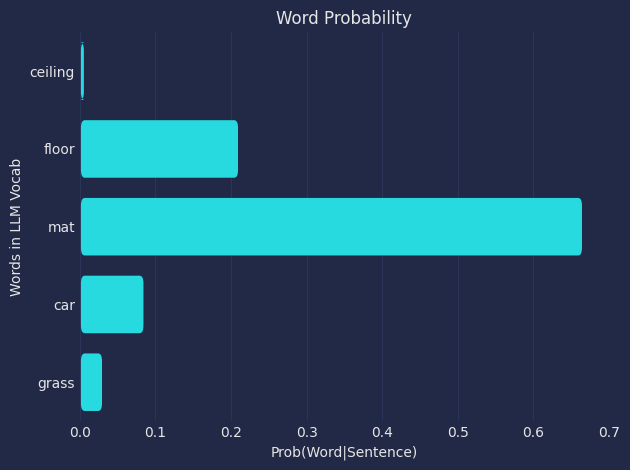

In [362]:
#| echo: false
fancy_box_plot(x = model_output["softmax_prob"], y = model_output["words"], xlim = [0, 0.7]) 

In [364]:
#| echo: false
from IPython.display import display_markdown
print_this =\
    f"\nFrom the softmax probabilities we see that the most probable word is: { style_text(model_output['words'][most_prob] ,color='green', style = 'bold') } " \
    f"with a probability of : {  style_text(np.round(model_output['softmax_prob'][most_prob],3), color='green', style = 'bold')}"\
    "\n\n" 

display_markdown(print_this, raw=True)


From the softmax probabilities we see that the most probable word is: <span style='color: green; font-weight: bold'>mat</span> with a probability of : <span style='color: green; font-weight: bold'>0.666</span>



</details>
<details>
<summary>**Temperature: 100.0**</summary>

**By Hand:**

In [371]:
#| echo: false
# Generate and display the aligned equations
x = [-49.82, -46.40, -45.25, -47.30, -48.32]

temp_in = 100.0
latex_output = generate_softmax_steps(x, temp_in, precision=4, notation='g')
display(Math(latex_output))

<IPython.core.display.Math object>

**Using Python:**

In [325]:
# Example Softmax Calculation

# Assume for simplicity:
# * The model only knows the 5 words listed below (it has a vocabulary of 5).

import pandas as pd
import seaborn as sns

#Example model output
model_output_vals = {"word_index":[i for i in range(5)],
                "words":["ceiling", "floor", "mat", "car", "grass"], 
                "logits":[-49.82, -46.40, -45.25, -47.30, -48.32]}
temp = 100.0
#Convert the data to a DataFrame
model_output = pd.DataFrame(model_output_vals)

#Define a softmax function with temperature
def my_softmax(input_vector, Temp=1.0):
    e = np.exp(np.divide(input_vector,Temp))
    return e / e.sum()

#Calculate the probabilities
probs =  my_softmax(model_output["logits"], Temp=temp)
model_output["softmax_prob"] = probs 

#Select the most probable word
most_prob = np.argmax(probs)

print(f"\nThe index of the most probable word is: {most_prob}")

#Pull out the most probable word
print(f"\nThe most probable word is: { model_output['words'][most_prob] }" \
      f" (Prob: {model_output['softmax_prob'][most_prob]:.5f})")


#Style our table
cm = sns.light_palette("orange", as_cmap=True)
s1 = model_output
s1 = s1.style.background_gradient(subset=["logits"],cmap=cm)

cm = sns.light_palette("green", as_cmap=True)
s1.background_gradient(subset=["softmax_prob"],cmap=cm)


The index of the most probable word is: 2

The most probable word is: mat (Prob: 0.20436)


,word_index,words,logits,softmax_prob
0,0,ceiling,-49.820000,0.195229
1,1,floor,-46.400000,0.202022
2,2,mat,-45.250000,0.204358
3,3,car,-47.300000,0.200211
4,4,grass,-48.320000,0.198180


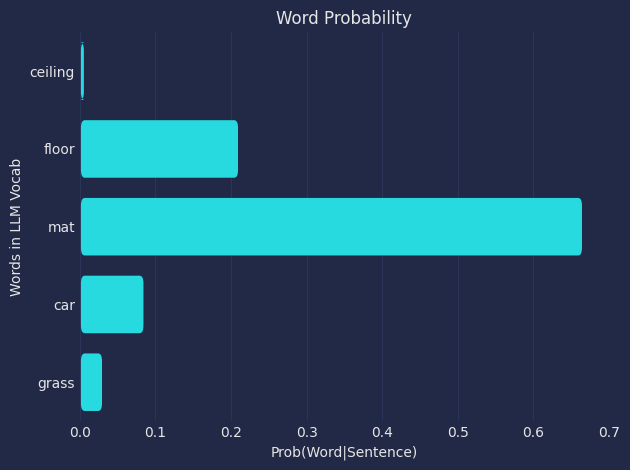

In [385]:
#| echo: false
df_sorted=model_output.nlargest(3, 'softmax_prob') 
fancy_box_plot(x = model_output["softmax_prob"], y = model_output["words"], xlim = [0, 0.7]) 

In [391]:
#| echo: false
#| output: asis
from IPython.display import display_markdown
print_this =\
    f"\nFrom the softmax probabilities we see that the most probable word is: { style_text(model_output['words'][most_prob] ,color='green', style = 'bold') } " \
    f"with a probability of : {  style_text(np.round(model_output['softmax_prob'][most_prob],3), color='green', style = 'bold')}"  \
    "\n"\

display_markdown(print_this, raw=True)


From the softmax probabilities we see that the most probable word is: <span style='color: green; font-weight: bold'>mat</span> with a probability of : <span style='color: green; font-weight: bold'>0.666</span>


In [393]:
#| echo: false
#| output: asis

from IPython.display import display_markdown


print_this =\
    "</details>"\
    "<details>"\
    "<summary>**What does this mean?**</summary>"\
    "\n\n"\
    f"\nBetween the temperature values of **1.0** and **100.0** we see that the probability distribution goes from being **more 'peaky'** to **more 'flat'** or uniform.\n" \
    "This means that words that would have a low chance of being chosen when the temperature is low would now have a higher chance of being chosen. \n" \
    "\n\n"\
    "Since we're using **greedy sampling**, the word with the highest probability always gets select, but if we change our method to randomly pick a word from the top 3 probabilites, the possible choices become: "\
    f"**{df_sorted['words'].values}**"\
    "\n"\


display_markdown(print_this, raw=True)

</details><details><summary>**What does this mean?**</summary>


Between the temperature values of **1.0** and **100.0** we see that the probability distribution goes from being **more 'peaky'** to **more 'flat'** or uniform.
This means that words that would have a low chance of being chosen when the temperature is low would now have a higher chance of being chosen. \n

Since we're using **greedy sampling**, the word with the highest probability always gets select, but if we change our method to randomly pick a word from the top 3 probabilites, the possible choices become: **['mat' 'floor' 'car']**


</details>

### LLM with Temperature Applied

To see how the temperature parameter affects the LLM outputs we'll use the [GPT-2 model by OpenAI](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) for text generation. The GPT-2 model is a fairly small, open sourced model that can be accessed and used via [Hugging Face](https://huggingface.co/docs/transformers/model_doc/gpt2).<br>
GPT-2 has:

 - 1.5 billion parameters

 - 50257 vocabulary size (number of words it knows)

 - 768 vector embedding size

 - 12 attention heads

 - 12 layers 

<br>
We'll look at using the LLM for two types of task:

* Single next word generation
* Continuous next word generation 

</details>
<details>
<summary>**Model Set up**</summary>

To get the model(`gpt2`) we download it from Hugging Face and set the model's task to `text-generation`


```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model_to_load = "openai-community/gpt2"
model_to_load_task = "text-generation"

# Load the model's pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_to_load)

# Load the pretrained model
model = AutoModelForCausalLM.from_pretrained(
    model_to_load,
    device_map = device, #CPU or GPU
    torch_dtype = "auto",
    trust_remote_code = True
)
```


To pass inputs to the model we can run the following

```python
# Input sentence
prompt = "The cat sat on the"

# Tokenize/encode input prompt
input_ids = tokenizer.encode(prompt, return_tensors="pt")

# Generate the output with adjusted temperature
outputs = model.generate(input_ids,
                        max_new_tokens=1, #Just want one word generated
                        temperature=temperature, #Set temp
                        output_scores=True, #Output model word scores
                        output_logits=True, #Outout logits
                        return_dict_in_generate=True,
                        do_sample=True, #Perform sampling for next word
                        pad_token_id=tokenizer.eos_token_id)


# Get the generated token ID/next word
generated_token_id = outputs.sequences[0][-1].item()    


# Decode the generated token ID to a word
generated_word = tokenizer.decode([generated_token_id])

```

In [412]:
#| echo: false
#| output: asis

#Define Set up code

#==============================================================
#PyToch Set up
import torch
torch.manual_seed(0)
torch.cuda.device_count()
# print(torch.cuda.get_device_name())
# Check if a GPU is available
if torch.cuda.is_available():
    # Set the device to the first GPU (index 0)
    device = torch.device("cuda:1")
else:
    device = torch.device("cpu")


#==============================================================
# Set up access tokens
try:
  from google.colab import userdata
  def get_api_key(key_name):
    return userdata.get(key_name)

except:
  from dotenv import load_dotenv, dotenv_values
  load_dotenv()
  def get_api_key(key_name):
    return os.environ.get(key_name)    
  

#==============================================================
#Download and load the model
#Download the model 
from transformers import AutoModelForCausalLM, AutoTokenizer

model_to_load = "openai-community/gpt2"
model_to_load_task = "text-generation"

#Load the model's pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_to_load)

#Load the pretrained model
model = AutoModelForCausalLM.from_pretrained(
    model_to_load,
    device_map = device,
    torch_dtype = "auto",
    trust_remote_code = True
)

# Enable gradient checkpointing
model.gradient_checkpointing_enable()

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [469]:
#| echo: false
#| output: asis

# Define LLM helper functions 

#==============================================================
#Bar chart of selected outputs

# def plot_bar_chart(words, probs, temp=None):
#     """
#     Plots a bar chart of words and their probabilities
#     """

#     # Extract the values for Plotly
#     words = words
#     probs = probs 
#     colors = [f"C{i}" for i in range(len(words))]


#     plot_params = {
#       'xlabel': 'Words in LLM Vocab',
#       'ylabel': 'Prob(Word|Sentence)',
#       'title': f"Word Probability at Temp: {temp:.2f}"}

#     # plt.figure(figsize=(4,2))
#     plt.style.use('cyberpunk')
#     fig, ax = plt.subplots(figsize=(8,4))
#     bars = ax.bar(words, probs, color=colors, zorder=2)
#     mplcyberpunk.add_bar_gradient(bars=bars)
#     ax.set(**plot_params)
#     plt.show()

def plot_bar_chart(words, probs, temp=None, ax=None):
    """
    Plots a bar chart of words and their probabilities
    """
    # If no axis is provided, create one
    if ax is None:
        plt.style.use('cyberpunk')
        fig, ax = plt.subplots(figsize=(8,4))

    colors = [f"C{i}" for i in range(len(words))]


    plot_params = {
      'xlabel': 'Words in LLM Vocab',
      'ylabel': 'Prob(Word|Sentence)',
      'title': f"Word Probability at Temp: {temp:.2f}"}

    # Create the plot on the specified axis
    bars = ax.bar(words, probs, color=colors, zorder=2)
    mplcyberpunk.add_bar_gradient(bars=bars)
    ax.set(**plot_params)
    
    # Only show if we created a new figure
    if ax is None:
        plt.show()
        

#==============================================================
#Function to get the next predicted word

def next_word_prediction(prompt: str, temp=0.5, 
                         output_bar_chart=False,
                         output_probs=False, 
                         words_to_plot=None,
                         ax = None,
                         verbose = False):
  """
  Extracts next word prediction from the defined LLM
  """
  # Tokenize/encode input prompt
  input_ids = tokenizer.encode(prompt, return_tensors="pt")

  # Pass to GPU
  input_ids = input_ids.to("cuda:1")
  temperature =temp#0.75#10.#0.001
  # Generate the output with adjusted temperature
  outputs = model.generate(input_ids,
                            max_new_tokens=1, #Just want one word generated
                            temperature=temperature, #Set temp
                            output_scores=True, #Output model word scores
                            output_logits=True, #Outout logits
                            return_dict_in_generate=True,
                            do_sample=True, #Perform sampling for next word
                            pad_token_id=tokenizer.eos_token_id)

  # Get the generated token ID, logit, and probability
  generated_token_id = outputs.sequences[0][-1].item()
  generated_token_logit = outputs.logits[0][0][generated_token_id]
  softmax_prob =  F.softmax(outputs.logits[0][0]/torch.tensor([temperature]).to(device)  ,dim=-1)
  generated_token_prob = softmax_prob[generated_token_id].item()
  # Decode the generated token ID to a word
  generated_word = tokenizer.decode([generated_token_id])

  if verbose:
    print(f"Generated word: {generated_word} \
            ( token index: {generated_token_id},\
            logit:{generated_token_logit:.2f},\
            prob: {generated_token_prob:.4f} )")

  
  # Get logits for all tokens
  logits = outputs.logits[0][0]/torch.tensor([temperature]).to(device)

  # Apply softmax to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  all_words = [tokenizer.decode([idx]).replace(" ", "") for idx in range(len(probabilities))]

  # Get the top 10 probable words
  top_10_probabilities, top_10_indices = torch.topk(probabilities, 100)

  # Decode the top 10 tokens to words
  top_10_words = [tokenizer.decode([idx]).replace(" ", "") for idx in top_10_indices]

  if verbose and output_probs:
    # Print the table of probabilities
    print("Index\t \tWord\t \tProbability")
    print("-"*35)
    for indx, word, prob in zip(top_10_indices, top_10_words, top_10_probabilities):
        print(f"{indx} \t \t{word}\t \t{prob.item():.6f}")


  
    
  if words_to_plot is not None:
      
      words_in_encode = [tokenizer.encode(" "+word, return_tensors="pt") for word in words_to_plot]
    
      words_in_prob = [softmax_prob[idx[0]].cpu().numpy()[0] for idx in words_in_encode]

      # plot_bar_chart(words = words_to_plot, probs =  words_in_prob, temp=temp, ax = ax)

  else:
      words_in_prob = top_10_probabilities.cpu().numpy()
      words_to_plot = top_10_words
      # plot_bar_chart(words = words_to_plot, probs = words_in_prob , ax = ax)

  if output_bar_chart:
      plot_bar_chart(words = words_to_plot, probs = words_in_prob , ax = ax)
      
  plot_data = {'words': words_to_plot,
              'probs': words_in_prob}
  

  #Return the generated word
  return generated_word, plot_data 


</details>

#### Single next word generation

With single next word generation the model is given a sentence and is tasked with predicting the next most likely word. 

<br>
For example:
We'll pass the same sentence we've been looking at to the LLM to see what it will output. 

* Input sentence: The cat slept on the ______.



```python
prompt = "The cat slept on the"
temps = [0.1,  0.5, 1., 5., 10., 100.]
for ii in temps:
  word_out = next_word_prediction(prompt, temp=ii)

  print(f"LLM Temperature: {ii} \n {prompt} {word_out}")

```

Here we pass the same input sentence to the LLM with different temperature values and look at the probability distribution of select words in the model's vocabulary. 

Generated word:  floor         ( token index: 4314,          logit:-82.82,          prob: 0.9891 )


**LLM Temperature: 0.1**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> floor</span>

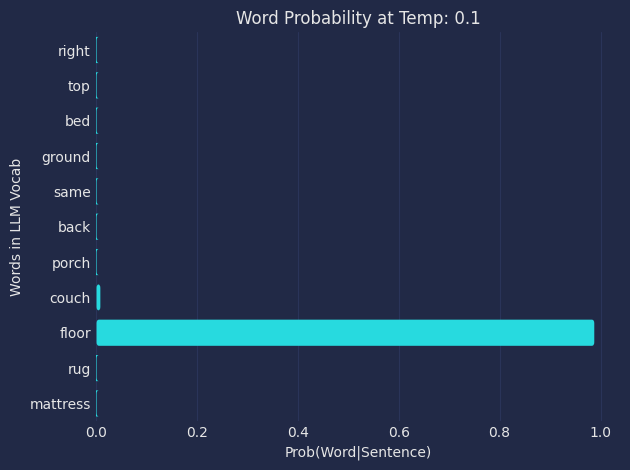

Generated word:  top         ( token index: 1353,          logit:-85.89,          prob: 0.0012 )


**LLM Temperature: 0.5**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> top</span>

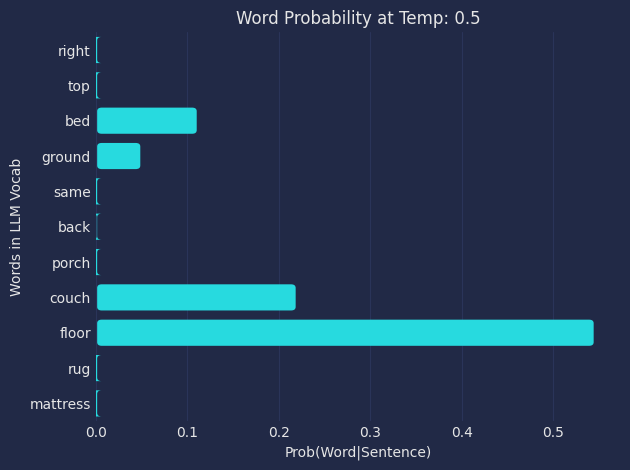

Generated word:  bed         ( token index: 3996,          logit:-83.61,          prob: 0.0857 )


**LLM Temperature: 1.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> bed</span>

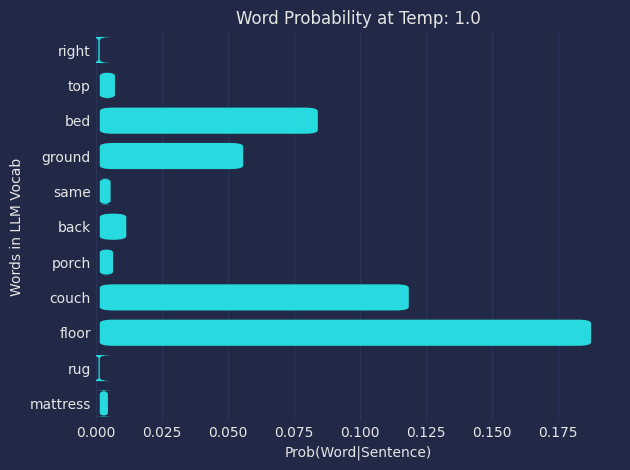

Generated word:  rug         ( token index: 14477,          logit:-87.13,          prob: 0.0002 )


**LLM Temperature: 5.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> rug</span>

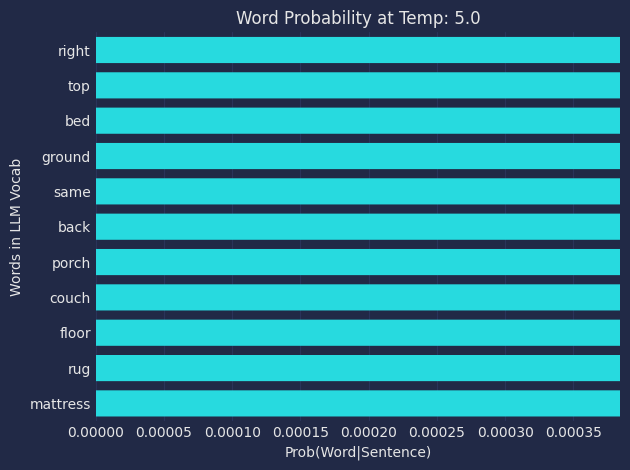

Generated word:  back         ( token index: 736,          logit:-85.49,          prob: 0.0001 )


**LLM Temperature: 10.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> back</span>

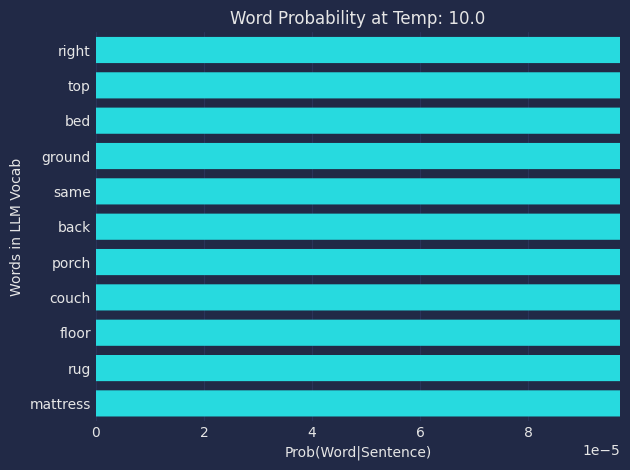

Generated word:  right         ( token index: 826,          logit:-87.17,          prob: 0.0000 )


**LLM Temperature: 100.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> right</span>

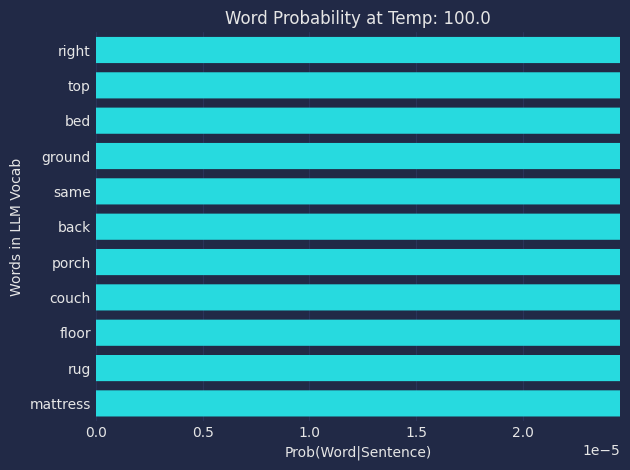

In [466]:
#| echo : false
import random
random.seed(0)
torch.manual_seed(0)
words_to_plot=["floor", "bed", "ground", "back", "couch", "same", "mattress", "porch", "right", "top", "rug"]
random.shuffle(words_to_plot)

prompt = "The cat slept on the"
temps = [0.1,  0.5, 1., 5., 10., 100.]
for ii in temps:
  # word_out, b = next_word_prediction(prompt, temp=ii, output_bar_chart=True, words_to_plot=words_to_plot)
  word_out, b = next_word_prediction(prompt, temp=ii, words_to_plot=words_to_plot)
  

  print_this =\
      f"**LLM Temperature: {ii}**"\
      "\n\n"\
      f"\n Input : {  style_text('The cat slept on the ', color='gray', style = 'underline')}" \
      "\n\n"\
      f"\n Output: {  style_text('The cat slept on the ', color='gray', style = 'underline')}  {  style_text(word_out, color='green', style = 'underline')}"  \


  display_markdown(print_this, raw=True)
  fancy_box_plot(x = b["probs"], y = b["words"], title=f"Word Probability at Temp: {ii}") 
  del b



**What does this mean?**

As the temperature increases from 0.1 to 100.0 the output words that were generated, generally all seem plausible. 

Looking at the distribution of words we see that going from 0.1 to 100.0 the distribution goes from being very "peaky" around the most likely word to flat across all words. 

This demonstrates how the temperature parameter affects the probability distribution of words from the LLM's vocabulary so that some are more or less likely to be selected as the next generated word in a sequence. 

#### Continuous next word generation

With continuous next word generation the model is given a sentence and is tasked with predicting the next most likely word in an autoregressive manner. The predicted word is added to the sentence and passed for the next iteration of prediction unit an end of sentence token (`<EOS>` or `\n`) is generated or the max number of iterations is reached. 

<br>
We'll pass the same sentence we've been looking at to the LLM to see what it will <span style="color:green"> output </span> over a number of iterations like below. 

* Input sentence: The cat slept on the ______
* 1: The cat slept on the <span style="color:green">floor</span>  ______
* 2: The cat slept on the floor <span style="color:green">next</span>  ______
* 3: The cat slept on the floor next <span style="color:green">to</span> ______
* 4: The cat slept on the floor next to <span style="color:green">the</span> ______
* 5: The cat slept on the floor next to the <span style="color:green">window</span> ______
* 6: The cat slept on the floor next to the window <span style="color:green">.</span> ______
* 7: The cat slept on the floor next to the window . <span style="color:green">< EOS ></span>


We'll pass the `prompt` to the LLM and append its predicted output (`word_out`) to the prompt and keep iterating until we reach the max number of iterations (`max_gen_iteration`) or and end of sentence token (`<EOS>` or `\n`) is predicted.

```python
prompt = "The cat slept on the"
temp = 0.5
max_gen_iteration = 15
for ii in range(max_gen_iteration):
  word_out, probs_out = next_word_prediction(prompt, temp=temp)
  print(prompt + word_out)
  prompt += word_out

```

Here we pass the same input sentence to the LLM with different temperature values and look at the probability distribution of select words in the model's vocabulary. 

<details>
<summary>**Temp: 0.5**</summary>


Parameters:

* Input text: "The cat slept on the"
* Temperature: 0.5
* Max iterations: 20

In [486]:
#| echo : false
prompt = "The cat slept on the"
temp = 0.5
torch.manual_seed(0)
def gen_next_word_loop(prompt, temp=0.5, max_iter=10):
    for ii in range(max_iter):
        word_out, probs_out= next_word_prediction(prompt, temp=temp)
        if word_out == prompt[-1]:
            break
        print_this = f"{style_text(prompt, color='gray', style = 'underline')}{  style_text(word_out, color='green', style = 'underline')}"
        display_markdown(print_this, raw=True)
        prompt+= word_out

In [488]:
prompt = "The cat slept on the"
temp = 0.5
max_iter = 20

gen_next_word_loop(prompt, temp = temp, max_iter = max_iter)

<span style='color: gray; text-decoration: underline'>The cat slept on the</span><span style='color: green; text-decoration: underline'> floor</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor</span><span style='color: green; text-decoration: underline'> of</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of</span><span style='color: green; text-decoration: underline'> the</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the</span><span style='color: green; text-decoration: underline'> cabin</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin</span><span style='color: green; text-decoration: underline'> for</span>

...

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin for a few hours before it was taken</span><span style='color: green; text-decoration: underline'> to</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin for a few hours before it was taken to</span><span style='color: green; text-decoration: underline'> the</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin for a few hours before it was taken to the</span><span style='color: green; text-decoration: underline'> shelter</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin for a few hours before it was taken to the shelter</span><span style='color: green; text-decoration: underline'>.</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the floor of the cabin for a few hours before it was taken to the shelter.</span><span style='color: green; text-decoration: underline'>
</span>

</details>
<details>
<summary>**Temp: 2.0**</summary>


Parameters:

* Input text: "The cat slept on the"
* Temperature: 2.0
* Max iterations: 20

In [490]:
prompt = "The cat slept on the"
temp = 2.0
max_iter = 20

gen_next_word_loop(prompt, temp = temp, max_iter = max_iter)

<span style='color: gray; text-decoration: underline'>The cat slept on the</span><span style='color: green; text-decoration: underline'> inside</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside</span><span style='color: green; text-decoration: underline'>,</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside,</span><span style='color: green; text-decoration: underline'> trying</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying</span><span style='color: green; text-decoration: underline'> the</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the</span><span style='color: green; text-decoration: underline'> inside</span>

...

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the inside-out of these chairs. She was being fed</span><span style='color: green; text-decoration: underline'> from</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the inside-out of these chairs. She was being fed from</span><span style='color: green; text-decoration: underline'> one</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the inside-out of these chairs. She was being fed from one</span><span style='color: green; text-decoration: underline'>,</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the inside-out of these chairs. She was being fed from one,</span><span style='color: green; text-decoration: underline'> her</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the inside, trying the inside-out of these chairs. She was being fed from one, her</span><span style='color: green; text-decoration: underline'> two</span>

</details>
<details>
<summary>**Temp: 10.0**</summary>


Parameters:

* Input text: "The cat slept on the"
* Temperature: 10.0
* Max iterations: 20

In [491]:
prompt = "The cat slept on the"
temp = 10.0
max_iter = 20

gen_next_word_loop(prompt, temp = temp, max_iter = max_iter)

<span style='color: gray; text-decoration: underline'>The cat slept on the</span><span style='color: green; text-decoration: underline'> left</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left</span><span style='color: green; text-decoration: underline'> one</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one</span><span style='color: green; text-decoration: underline'> piece</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece</span><span style='color: green; text-decoration: underline'> side</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side</span><span style='color: green; text-decoration: underline'> at</span>

...

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side at day one! [laughs about how long they both</span><span style='color: green; text-decoration: underline'> would</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side at day one! [laughs about how long they both would</span><span style='color: green; text-decoration: underline'> lie</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side at day one! [laughs about how long they both would lie</span><span style='color: green; text-decoration: underline'> still</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side at day one! [laughs about how long they both would lie still</span><span style='color: green; text-decoration: underline'> at</span>

<span style='color: gray; text-decoration: underline'>The cat slept on the left one piece side at day one! [laughs about how long they both would lie still at</span><span style='color: green; text-decoration: underline'> sunrise</span>

</details>

**What does this mean?**

If we look at the outputs between a temperature of 0.5 vs 10.0, we see that at a temperature of 0.5 the output text is more coherent whereas for a temperature of 10.0 the output is more incoherent and does not make sense to a human reader. 

This demonstrates how the temperature parameter can influence the next generated word by adjusting the probability distribution of words within the LLM's vocabulary. 

## CURRENT WORK

[DYNAMIC TEMPERATURE ]

Generated word:  porch         ( token index: 33179,          logit:-85.97,          prob: 0.0000 )
{'words': ['porch', 'same', 'bed', 'back', 'couch', 'ground', 'floor', 'right', 'mattress'], 'probs': [2.0423095e-05, 2.0417958e-05, 2.0519803e-05, 2.044276e-05, 2.0533693e-05, 2.0503358e-05, 2.0552357e-05, 2.0374422e-05, 2.0411651e-05]}


**LLM Temperature: 500.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> porch</span>

Generated word:  top         ( token index: 1353,          logit:-85.89,          prob: 0.0000 )
{'words': ['porch', 'same', 'bed', 'back', 'couch', 'ground', 'floor', 'right', 'mattress'], 'probs': [2.0423095e-05, 2.0417958e-05, 2.0519803e-05, 2.044276e-05, 2.0533693e-05, 2.0503358e-05, 2.0552357e-05, 2.0374422e-05, 2.0411651e-05]}


**LLM Temperature: 500.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> top</span>

Generated word:  ceiling         ( token index: 13387,          logit:-87.47,          prob: 0.0000 )
{'words': ['porch', 'same', 'bed', 'back', 'couch', 'ground', 'floor', 'right', 'mattress'], 'probs': [2.0423095e-05, 2.0417958e-05, 2.0519803e-05, 2.044276e-05, 2.0533693e-05, 2.0503358e-05, 2.0552357e-05, 2.0374422e-05, 2.0411651e-05]}


...

**LLM Temperature: 500.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> living</span>

Generated word:  back         ( token index: 736,          logit:-85.49,          prob: 0.0000 )
{'words': ['porch', 'same', 'bed', 'back', 'couch', 'ground', 'floor', 'right', 'mattress'], 'probs': [2.0423095e-05, 2.0417958e-05, 2.0519803e-05, 2.044276e-05, 2.0533693e-05, 2.0503358e-05, 2.0552357e-05, 2.0374422e-05, 2.0411651e-05]}


**LLM Temperature: 500.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> back</span>

Generated word:  right         ( token index: 826,          logit:-87.17,          prob: 0.0000 )
{'words': ['porch', 'same', 'bed', 'back', 'couch', 'ground', 'floor', 'right', 'mattress'], 'probs': [2.0423095e-05, 2.0417958e-05, 2.0519803e-05, 2.044276e-05, 2.0533693e-05, 2.0503358e-05, 2.0552357e-05, 2.0374422e-05, 2.0411651e-05]}


**LLM Temperature: 500.0**


 Input : <span style='color: gray; text-decoration: underline'>The cat slept on the </span>


 Output: <span style='color: gray; text-decoration: underline'>The cat slept on the </span>  <span style='color: green; text-decoration: underline'> right</span>

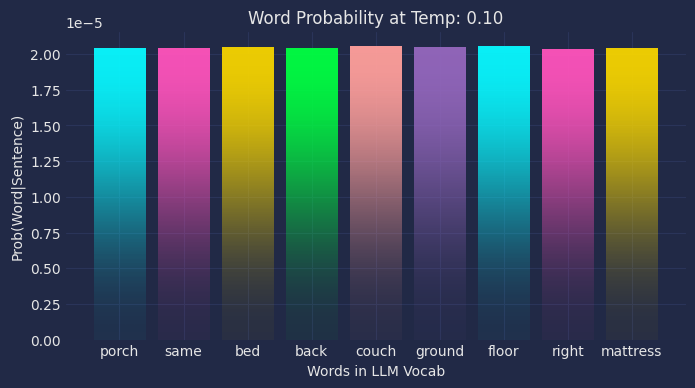

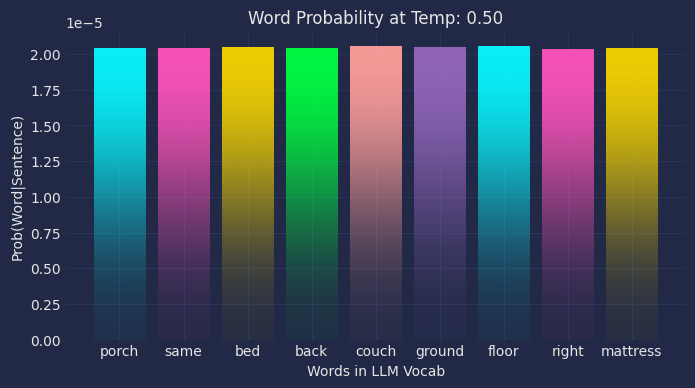

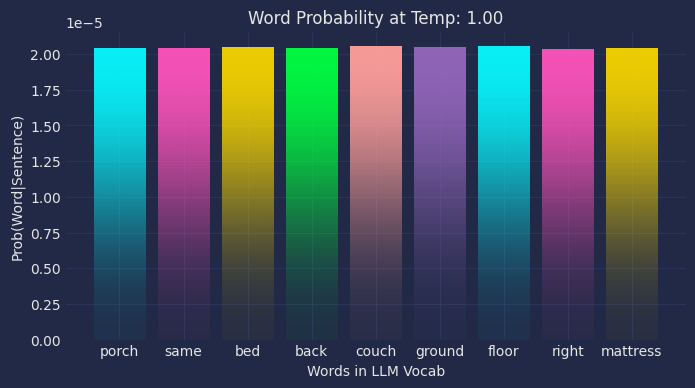

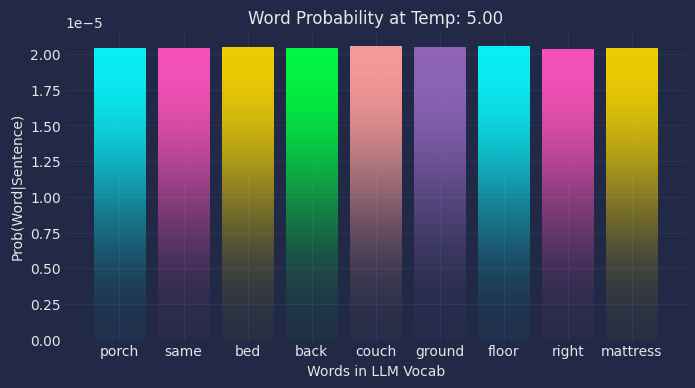

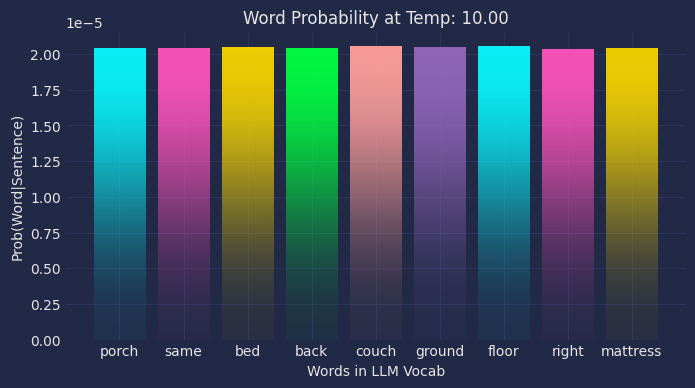

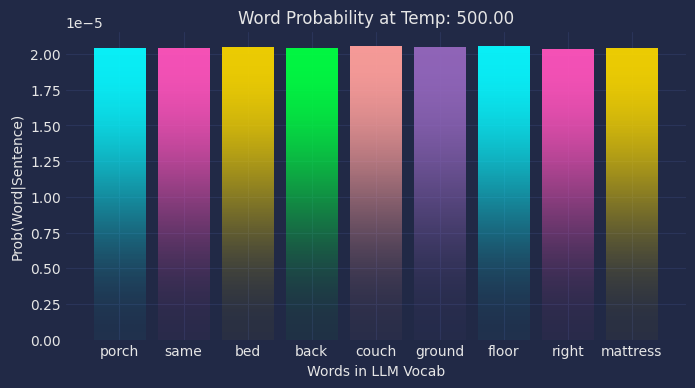

In [457]:
#| echo : false
import random
random.seed(0)
torch.manual_seed(0)
words_to_plot=["floor", "bed", "ground", "back", "couch", "same", "mattress", "porch", "right"]
random.shuffle(words_to_plot)

# plt.style.use('cyberpunk')
# fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# axes = axes.flatten()


prompt = "The cat slept on the"
temps = [0.1,  0.5, 1.,  5., 10., 500.]
for index, temp in enumerate(temps):
  # word_out, b = next_word_prediction(prompt, temp=ii, output_bar_chart=True, words_to_plot=words_to_plot)
  word_out, b = next_word_prediction(prompt, temp=ii, words_to_plot=words_to_plot)
  # plt.show()
  print(b)
  plot_bar_chart(words = b['words'], probs = b['probs'], temp=temp)
  print_this =\
      f"**LLM Temperature: {ii}**"\
      "\n\n"\
      f"\n Input : {  style_text('The cat slept on the ', color='gray', style = 'underline')}" \
      "\n\n"\
      f"\n Output: {  style_text('The cat slept on the ', color='gray', style = 'underline')}  {  style_text(word_out, color='green', style = 'underline')}"  \


  display_markdown(print_this, raw=True)
  

  
  # plt.tight_layout()
  # plt.show()

In [173]:
#| echo: false
from IPython.display import display_markdown

var = 12
print_this =\
    f"\nFrom the softmax probabilities we see that the most probable word is: `{ model_output['words'][most_prob] }` " \
    f" (Prob: {model_output['softmax_prob'][most_prob]:.5f})"

# display_markdown(print_this, raw=True)
# display_markdown(f"This is a test to display {var}"+ r"$$\Sigma$$", raw=True)


# If you want to store the color in a variable:
color = "green"
display_markdown(f"This is a <span style='color: {color}'>test</span> to display {var}"+ r"$$\Sigma$$", raw=True)


def style_text(text, color=None, style=None):
    styled_text = str(text)



    # Build CSS style string
    css_styles = []
    if color:
        css_styles.append(f"color: {color}")

    if style:
        style_map = {
            'bold': 'font-weight: bold',
            'italic': 'font-style: italic', 
            'underline': 'text-decoration: underline'
        }
        if style in style_map:
            css_styles.append(style_map[style])

    # Apply HTML styling if any styles specified
    if css_styles:
        style_str = '; '.join(css_styles)
        styled_text = f"<span style='{style_str}'>{styled_text}</span>"
        
    return styled_text


# Example usage:
text = "Hello World"
display_markdown(style_text(text,color='green', style = 'bold'), raw=True)

This is a <span style='color: green'>test</span> to display 12$$\Sigma$$

<span style='color: green; font-weight: bold'>Hello World</span>

In [139]:
from IPython.display import display_markdown

display_markdown('''## heading
- ordered
- list

The table below:

| id |value|
|:---|----:|
| a  |  1  |
| b  |  2  |
''', raw=True)

## heading
- ordered
- list

The table below:

| id |value|
|:---|----:|
| a  |  1  |
| b  |  2  |


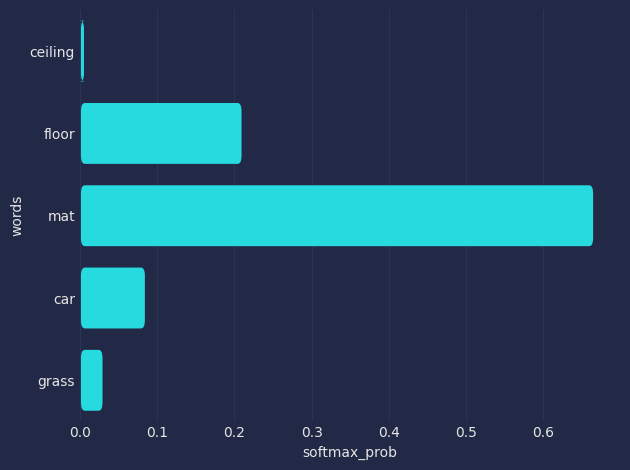

In [281]:
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

def my_func(x, y):
    plt.figure()
    # plt.subplots(figsize=(5, 2))
    sns.set_color_codes("pastel")
    ax = sns.barplot(y = y, 
                    x = x, 
                                    orient = "h", 
                                    joinstyle='bevel')

    new_patches = []
    for patch in reversed(ax.patches):
        bb = patch.get_bbox()
        color = patch.get_facecolor()
        p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                                abs(bb.width), abs(bb.height),
                                boxstyle="round,pad=-0.00150,rounding_size=0.005",
                                ec="none", fc=color,
                                mutation_aspect=20
                                )
        patch.remove()
        new_patches.append(p_bbox)

    for patch in new_patches:
        ax.add_patch(patch)

    sns.despine(left=True, bottom=True)
    ax.tick_params(axis=u'both', which=u'both', length=0)
    plt.tight_layout()
    plt.show()

my_func(x = model_output["softmax_prob"], y = model_output["words"])    

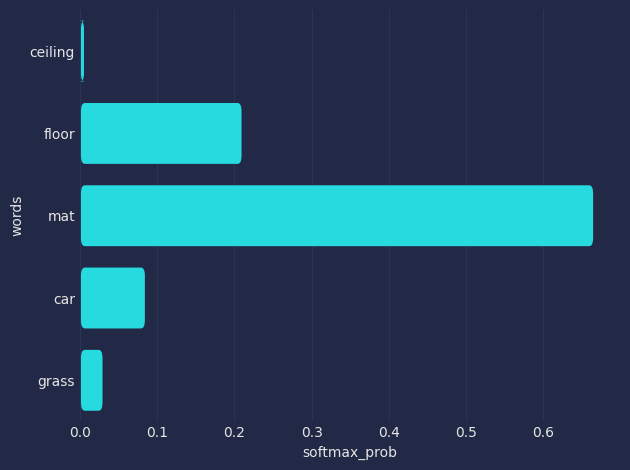

In [275]:
from matplotlib.patches import FancyBboxPatch

# plt.subplots(figsize=(5, 2))
sns.set_color_codes("pastel")
ax = sns.barplot(y = model_output.words, 
                 x = model_output.softmax_prob, 
                                orient = "h", 
                                joinstyle='bevel')

new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color = patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                            abs(bb.width), abs(bb.height),
                            boxstyle="round,pad=-0.00150,rounding_size=0.005",
                            ec="none", fc=color,
                            mutation_aspect=20
                            )
    patch.remove()
    new_patches.append(p_bbox)

for patch in new_patches:
    ax.add_patch(patch)

sns.despine(left=True, bottom=True)
ax.tick_params(axis=u'both', which=u'both', length=0)
plt.tight_layout()
plt.show()


# #   joinstyle='bevel', 
# new_patches = []
# for patch in reversed(ax.patches):
#     # print(bb.xmin, bb.ymin,abs(bb.width), abs(bb.height))
#     bb = patch.get_bbox()
#     color = patch.get_facecolor()
#     p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
#                             abs(bb.width), abs(bb.height),
#                             boxstyle="round,pad=-0.05,rounding_size=2",
#                             ec="none", fc=color,
#                             mutation_aspect=0.1
#                             )
#     patch.remove()
#     new_patches.append(p_bbox)

# for patch in new_patches:
#     ax.add_patch(patch)

# sns.despine(left=True, bottom=True)

# ax.tick_params(axis=u'both', which=u'both', length=0)
# plt.tight_layout()
# # plt.savefig("data.png", bbox_inches="tight")
# plt.show()




# #Plot the outcomes
# fig, ax = plt.subplots()
# bars = ax.barh(model_output.words[::-1], 
#         model_output.softmax_prob[::-1])


# # bars = plt.barh(model_output.words[::-1], 
# #         model_output.softmax_prob[::-1])

# # Function to create rounded bars
# def round_bar(x, y, width, height, color):
#     bbox = FancyBboxPatch((x, y), width, height,
#                           boxstyle="round,pad=0.1",
#                           edgecolor='black',
#                           facecolor=color)
#     return bbox

# # Replace bars with rounded bars
# for bar in bars:
#     bbox = round_bar(bar.get_x(), bar.get_y(), bar.get_width(), bar.get_height(), bar.get_facecolor())
#     ax.add_patch(bbox)
#     bar.set_visible(False)



#### The Softmax Function



### Example - Temperature Calculation



## Examples or Varying Temperature
Let's dive in with some examples. <br>
To see how the temperature parameter affects the LLM outputs we'll use the [GPT-2 model by OpenAI](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) for text generation. The GPT-2 model is a fairly small, open sourced model that can be accessed and used via [Hugging Face](https://huggingface.co/docs/transformers/model_doc/gpt2).<br>
GPT-2 has:

 - 1.5 billion parameters

 - 50257 vocabulary size (number of words it knows)

 - 768 vector embedding size

 - 12 attention heads

 - 12 layers 

### Examples 1 - Next word generation
Suppose we’re given a sentence; how does temperature affect the next predicted word? 

Sentence: The cat slept on the ______.


### Example 2- Continuous word generation
How does temperature affect the output of continuous next word generation? 

Temp: 0.25

Sentence: The cat slept on the ______.

Sentence: The cat slept on the floor ______.

Sentence: The cat slept on the floor at ______.

Sentence: The cat slept on the floor at night ______.



Temp: 0.5
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.


Temp: 2.0
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.


Temp: 3.0
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.




## LLM Recap
LLMs work as next word prediction machines, given some input (over simplified). Those next word predictions come from a probability distribution of all the words that the model knows (its vocabulary). Layers within the transformer architecture (the structure that makes LLMs) produce logits, which are transformed to a probability distribution using a **softmax function**.




### The Softmax function
The softmax function is a widely used mathematical transformation that takes a set of values and transforms them into a set of probabilities that sum to 1. 

In [299]:
model_output.words[::-1]

4      grass
3        car
2        mat
1      floor
0    ceiling
Name: words, dtype: object

In [245]:
model_output["words"][2]

'mat'

In [237]:
vect = [1, 3, 2]
e = np.exp(vect)
print(e)
print(e.sum())

print(my_softmax(vect))

[ 2.71828183 20.08553692  7.3890561 ]
30.19287485057736
[0.09003057 0.66524096 0.24472847]


In [231]:
#| echo: false
import os
from tqdm import tqdm
import numpy as np

In [2]:
import torch
torch.cuda.device_count()
# print(torch.cuda.get_device_name())
# Check if a GPU is available
if torch.cuda.is_available():
    # Set the device to the first GPU (index 0)
    device = torch.device("cuda:1")
else:
    device = torch.device("cpu")

In [3]:
import torch
def list_cuda_devices():
    if torch.cuda.is_available():
        num_devices = torch.cuda.device_count()
        print("Number of CUDA devices:", num_devices)
        for i in range(num_devices):
            device_name = torch.cuda.get_device_name(i)
            print(f"Device {i}: {device_name}")
    else:
        print("No CUDA devices found.")

list_cuda_devices()

Number of CUDA devices: 3
Device 0: Quadro RTX 4000
Device 1: Quadro M4000
Device 2: Quadro P1000


In [4]:
try:
  from google.colab import userdata
  def get_api_key(key_name):
    return userdata.get(key_name)

except:
  from dotenv import load_dotenv, dotenv_values
  load_dotenv()
  def get_api_key(key_name):
    return os.environ.get(key_name)

In [5]:
#Download the model 
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model_to_load = "openai-community/gpt2" #"microsoft/Phi-3-mini-4k-instruct"
model_to_load_task = "text-generation"

#Load the model's pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_to_load)

#Load the pretrained model
model = AutoModelForCausalLM.from_pretrained(
    model_to_load,
    device_map = "cuda:1",
    torch_dtype = "auto",
    trust_remote_code = True
)

# Enable gradient checkpointing
model.gradient_checkpointing_enable()

2024-10-28 21:18:06.097403: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-28 21:18:06.113531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-28 21:18:06.133300: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-28 21:18:06.141213: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-28 21:18:06.156320: I tensorflow/core/platform/cpu_feature_guar

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Generated word:  floor         ( token index: 4314,          logit:-82.82,          prob: 1.0000 )


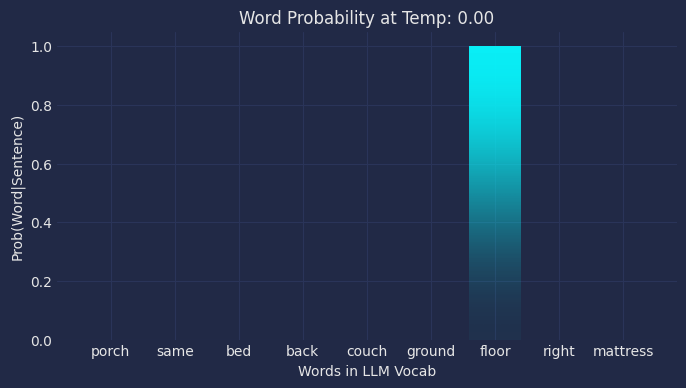

Generated word:  floor         ( token index: 4314,          logit:-82.82,          prob: 0.8213 )


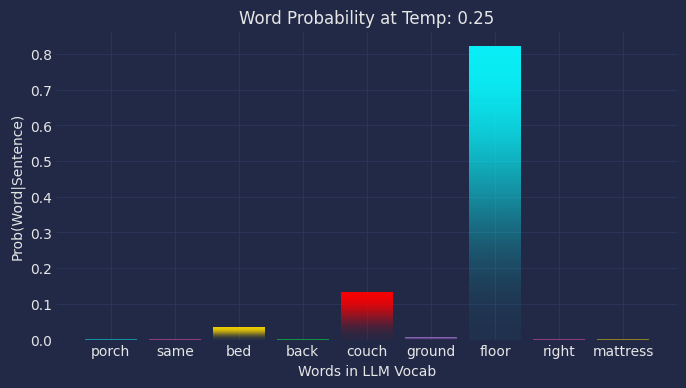

Generated word:  bed         ( token index: 3996,          logit:-83.61,          prob: 0.1118 )


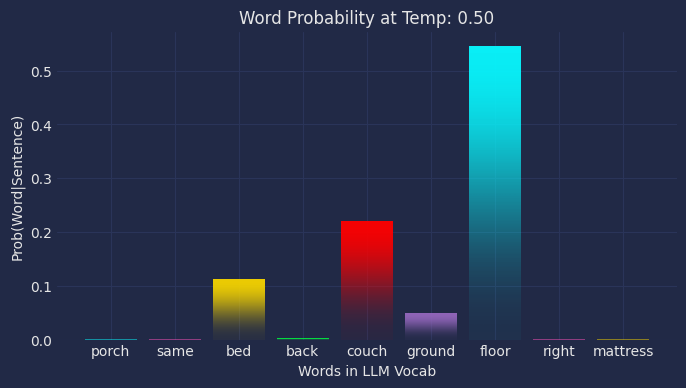

Generated word:  ground         ( token index: 2323,          logit:-84.01,          prob: 0.0574 )


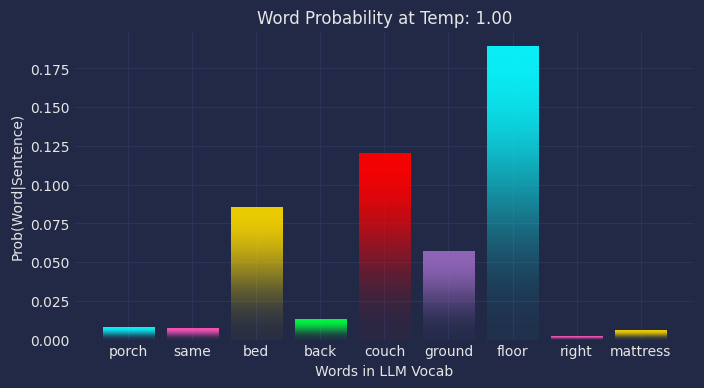

Generated word:  back         ( token index: 736,          logit:-85.49,          prob: 0.0027 )


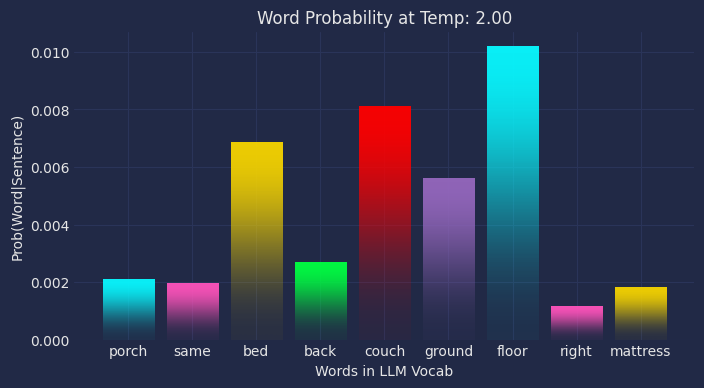

Generated word:  couch         ( token index: 18507,          logit:-83.27,          prob: 0.0003 )


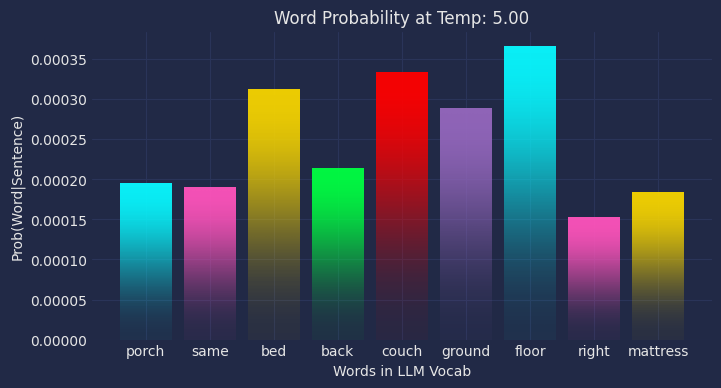

Generated word:  same         ( token index: 976,          logit:-86.10,          prob: 0.0001 )


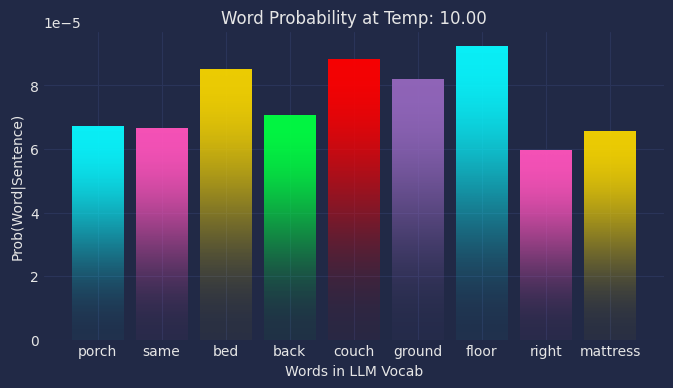

Generated word:  mattress         ( token index: 33388,          logit:-86.25,          prob: 0.0000 )


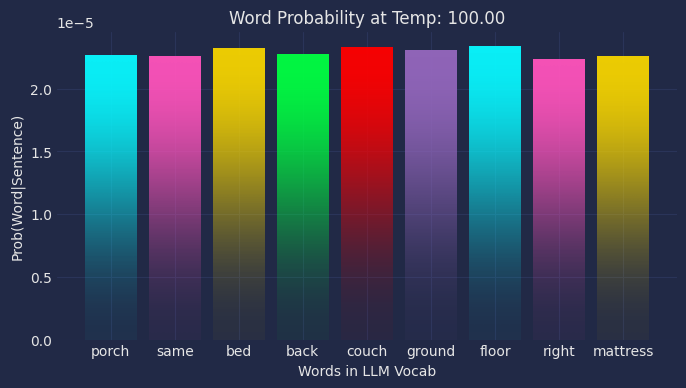

In [230]:
#| label: fig-gapminder
#| fig-cap: "Life Expectancy and GDP"
#| fig-subcap:
#|   - "Gapminder: 1957"

torch.manual_seed(0)
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

import seaborn as sns
import matplotlib.pyplot as plt
try: 
  import mplcyberpunk
except:
   %pip install mplcyberpunk
   import mplcyberpunk



def plot_bar_chart(words, probs, temp=None):
    """
    Plots a bar chart of words and their probabilities
    """

    # Extract the values for Plotly
    words = words
    probs = probs 
    colors = [f"C{i}" for i in range(len(words))]


    plot_params = {
      'xlabel': 'Words in LLM Vocab',
      'ylabel': 'Prob(Word|Sentence)',
      'title': f"Word Probability at Temp: {temp:.2f}"}

    # plt.figure(figsize=(4,2))
    plt.style.use('cyberpunk')
    fig, ax = plt.subplots(figsize=(8,4))
    bars = ax.bar(words, probs, color=colors, zorder=2)
    mplcyberpunk.add_bar_gradient(bars=bars)
    ax.set(**plot_params)
    plt.show()



def next_word_prediction(prompt: str, temp=0.5, 
                         output_bar_chart=False,
                         output_probs=False, 
                         words_to_plot=None):
  """
  Extracts next word prediction from the defined LLM
  """
  # Tokenize/encode input prompt
  input_ids = tokenizer.encode(prompt, return_tensors="pt")

  # Pass to GPU
  input_ids = input_ids.to("cuda:1")
  temperature =temp#0.75#10.#0.001
  # Generate the output with adjusted temperature
  outputs = model.generate(input_ids,
                            max_new_tokens=1, #Just want one word generated
                            temperature=temperature, #Set temp
                            output_scores=True, #Output model word scores
                            output_logits=True, #Outout logits
                            return_dict_in_generate=True,
                            do_sample=True, #Perform sampling for next word
                            pad_token_id=tokenizer.eos_token_id)

  # Get the generated token ID, logit, and probability
  generated_token_id = outputs.sequences[0][-1].item()
  generated_token_logit = outputs.logits[0][0][generated_token_id]
  softmax_prob =  F.softmax(outputs.logits[0][0]/torch.tensor([temperature]).to(device)  ,dim=-1)
  generated_token_prob = softmax_prob[generated_token_id].item()
  # Decode the generated token ID to a word
  generated_word = tokenizer.decode([generated_token_id])

  print(f"Generated word: {generated_word} \
        ( token index: {generated_token_id},\
          logit:{generated_token_logit:.2f},\
          prob: {generated_token_prob:.4f} )")

  
  # Get logits for all tokens
  logits = outputs.logits[0][0]/torch.tensor([temperature]).to(device)

  # Apply softmax to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  all_words = [tokenizer.decode([idx]).replace(" ", "") for idx in range(len(probabilities))]

  # Get the top 10 probable words
  top_10_probabilities, top_10_indices = torch.topk(probabilities, 100)

  # Decode the top 10 tokens to words
  top_10_words = [tokenizer.decode([idx]).replace(" ", "") for idx in top_10_indices]

  if output_probs:
    # Print the table of probabilities
    print("Index\t \tWord\t \tProbability")
    print("-"*35)
    for indx, word, prob in zip(top_10_indices, top_10_words, top_10_probabilities):
        print(f"{indx} \t \t{word}\t \t{prob.item():.6f}")


  if output_bar_chart:
     
    if words_to_plot is not None:
        
        words_in_encode = [tokenizer.encode(" "+word, return_tensors="pt") for word in words_to_plot]
      
        words_in_prob = [softmax_prob[idx[0]].cpu().numpy()[0] for idx in words_in_encode]

        plot_bar_chart(words = words_to_plot, probs =  words_in_prob, temp=temp)

    else:
        plot_bar_chart(words = top_10_words, probs =  top_10_probabilities.cpu().numpy())


  #Return the generated word
  return generated_word 



prompt = "The cat slept on the"
temps = [0.001, 0.25, 0.5, 1., 2., 5., 10., 100.]

# for i in temps:#range(10):
#   print(f"Temp: {i}")
#   generated_word  = next_word_prediction(prompt, temp=i)
#   # prompt += generated_word 
#   print(prompt + generated_word )
import random
words_to_plot=["floor", "bed", "ground", "back", "couch", "same", "mattress", "porch", "right"]
random.seed(0)
random.shuffle(words_to_plot)


for ii in temps:
  next_word_prediction(prompt, temp=ii, output_bar_chart=True, words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=0.25, output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=0.5, output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=1., output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=3., output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=100., output_bar_chart=True,  words_to_plot=words_to_plot)

In [188]:
# import torch
# torch.cuda.empty_cache()
# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [189]:
# import torch

# # Reset max memory allocated
# torch.cuda.reset_max_memory_allocated()

# # Reset max memory cached
# torch.cuda.reset_max_memory_cached()


/usr/local/lib/python3.11/dist-packages/torch/cuda/memory.py:343: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/cuda/memory.py:369: FutureWarning: torch.cuda.reset_max_memory_cached now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


In [23]:
# torch.cuda.empty_cache()
# print(torch.cuda.memory_allocated()/1024**2)
# print(torch.cuda.memory_reserved()/1024**2)
# torch.cuda.empty_cache()


7288.380859375
7290.0


In [26]:
# def empty_cache_on_device(device_id):
#     with torch.cuda.device(device_id):
#         torch.cuda.empty_cache()

# empty_cache_on_device(0)         

In [21]:
# import gc

# # Invoke garbage collector
# gc.collect()

740

In [193]:
#This works for clearing the current GPUs memory 
# torch.device("cuda:1")
# torch._C._cuda_clearCublasWorkspaces()
# torch._dynamo.reset()
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [28]:
#Generate LLM pipeline
#Create the generation pipeline
# LLM_generator = pipeline(
#     model_to_load_task,
#     model = model_to_load,
#     tokenizer = tokenizer,
#     return_full_text = False, 
#     max_new_tokens = 500,
#     do_sample = False, 
# )

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [31]:
# # Prompt
# prompt = "The capital of France is"
# messages = [{"role": "user", 
#             "content": prompt 
#             }]

# output = LLM_generator(messages) 
# print(output[0]["generated_text"])

 The capital of France is Paris.


In [ ]:
#| echo: false
#JUNK 


#     # Step 4: Softmax formula with temperature
#     r"\text{softmax}(x, " +  r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
#     ", ".join([f"\\frac{{e^{{{x[i]}/{red_T_marker}}}}}{{e^{{{x[0]}/{red_T_marker}}} + e^{{{x[1]}/{red_T_marker}}} + e^{{{x[2]}/{red_T_marker}}}}}" 
#             for i in range(n)]) + r"\right] \\",


#     # Step 4.1: Softmax formula with temperature
#     r"\text{softmax}(x, " +  r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
#     ", ".join([f"\\frac{{e^{{{x[i]}/{red_T}}}}}{{e^{{{x[0]}/{red_T}}} + e^{{{x[1]}/{red_T}}} + e^{{{x[2]}/{red_T}}}}}" 
#             for i in range(n)]) + r"\right] \\",




#     # Step 4: Softmax formula with temperature
#     r"\text{softmax}(x, " + f"{red_T}" + r") &= \left[" + 
#     ", ".join([f"\\frac{{e^{{{x[i]}/{red_T}}}}}{{e^{{{x[0]}/{red_T}}} + e^{{{x[1]}/{red_T}}} + e^{{{x[2]}/{red_T}}}}}" 
#             for i in range(n)]) + r"\right] \\",


            # # Step 4: Evaluate the exponential
            # r"\sum e^{x/" + f"{red_T}" + r"}" + "&= " + 
            # ' + '.join(f"e^{{{i}/{red_T}}}" for i in x) + r" \\",


            # # Step 4: Evaluate the exponential
            # r"\sum e^{x/" + f"{red_T}" + r"} &= " + 
            # ' + '.join(f"e^{{{i/temp}}}" for i in x) + r" \\",

In [27]:
# # Set up and prompt

# prompt = "The capital of France is"



# # Tokenize input prompt
# input_ids = tokenizer(prompt, return_tensors ="pt").input_ids
# #Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Get the output of the model before the lm_head
# model_output = model.model(input_ids)

# # Get the output of the lm_head
# lm_head_output = model.lm_head(model_output[0])

# token_id = lm_head_output[0,-1].argmax(-1)
# tokenizer.decode(token_id)

You are not running the flash-attention implementation, expect numerical differences.


'Paris'

In [67]:
# prompt = "The sleepy cat slept on the"#"The capital of France is"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors ="pt")
# #Pass to GPU
# input_ids = input_ids.to("cuda:1")


# outputs = model.generate(input_ids, 
#                          max_new_tokens=1, 
#                          output_scores=True, 
#                          return_dict_in_generate=True, 
#                          pad_token_id=tokenizer.eos_token_id)


# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)



Generated word: mat


In [9]:
# import torch.nn.functional as F

# # Assuming you have already imported and set up your tokenizer and model
# prompt = "The cat slept on the"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors="pt")

# # Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Forward pass to get logits for the next token
# with torch.no_grad():
#     outputs = model(input_ids)
#     logits = outputs.logits

# # Adjust temperature
# temperature = 100.0 # You can change this value to adjust the temperature
# scaled_logits = logits[0, -1, :] / temperature


# # Get the logits for the last token in the input sequence
# last_token_logits = scaled_logits# logits[0, -1, :]

# # Apply softmax to get probabilities
# probabilities = F.softmax(last_token_logits, dim=-1)

# # Get the top 10 probable words
# top_10_probabilities, top_10_indices = torch.topk(probabilities, 10)

# # Decode the top 10 tokens to words
# top_10_words = [tokenizer.decode([idx]) for idx in top_10_indices]

# print(f"The selected word: \n {prompt} {top_10_words[0]}")
# print("Top 10 probable next words:", top_10_words)

# # Print the table
# print("Word\tProbability")
# print("-"*20)
# for word, prob in zip(top_10_words, top_10_probabilities):
#     print(f"{word}\t{prob.item():.6f}")


# selected_idx = np.random.choice(top_10_indices.cpu(), p=top_10_probabilities.cpu().numpy()/sum(top_10_probabilities.cpu().numpy()))
# selected_word = tokenizer.decode([selected_idx.item()])

# print("Selected word:", selected_word)    


The selected word: 
 The cat slept on the  floor
Top 10 probable next words: [' floor', ' couch', ' bed', ' ground', ' sofa', ' side', ' other', ' roof', ' back', ' grass']
Word	Probability
--------------------
 floor	0.000023
 couch	0.000023
 bed	0.000023
 ground	0.000023
 sofa	0.000023
 side	0.000023
 other	0.000023
 roof	0.000023
 back	0.000023
 grass	0.000023
Selected word:  bed


In [97]:
# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)

AttributeError: 'CausalLMOutputWithPast' object has no attribute 'sequences'

In [13]:
# # Assuming you have already imported and set up your tokenizer and model
# prompt = "The cat slept on the"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors="pt")

# # Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Generate the output with adjusted temperature
# outputs = model.generate(input_ids,
#                           max_new_tokens=1,
#                           temperature= 2.0,  # You can change this value to adjust the temperature
#                           output_scores=True,
#                           return_dict_in_generate=True,
#                           do_sample=True,
#                           pad_token_id=tokenizer.eos_token_id)

# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)


Generated word:  grass


In [210]:
# probabilities.argmax().item()
# top_10_indices
# outputs.logits[0][0]/100
# top_10_indices
# [tokenizer.decode([idx]).replace(" ", "") for idx in top_10_indices]
# probabilities.sum()
# outputs.past_key_values
# model.config
# words_to_plot =["floor", "bed"]
# for word in words_to_plot:
#     print(tokenizer.encode(word, return_tensors="pt"))

GPT2Config {
  "_name_or_path": "openai-community/gpt2",
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.44.2",
  "use_cache": true,
  "vocab_size": 50257
}

In [70]:
# outputs.logits[0].size()
# print(F.softmax(outputs.logits[0][0]).argmax())
# print(outputs.sequences[0][-1])
# tokenizer.decode(outputs.sequences[0][-1])

tensor(4314, device='cuda:1')
tensor(4314, device='cuda:1')


/tmp/ipykernel_346/3335326152.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(outputs.logits[0][0]).argmax())


' floor'

In [81]:
# F.softmax(outputs.logits[0][0])[43].item()

/tmp/ipykernel_346/2671969968.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(outputs.logits[0][0])[43].item()


6.473852920407808e-08

In [ ]:
#JUNK


import latexify
import numpy as np

@latexify.function(align=True)  # Enable alignment
def generate_softmax_steps(x: list) -> str:
    """Generate steps for computing softmax of array x with centered alignment."""
    n = len(x)
    
    # Build aligned equation string using LaTeX align environment
    equations = [
        #  "\\begin{align}\n",
        # Step 1: Input array
        f"x &= [{', '.join(str(i) for i in x)}] \\\\",
        
        # Step 2: Exponentials
        f"e^x &= [{', '.join(f'e^{{{i}}}' for i in x)}] \\\\",
        
        # Step 3: Sum of exponentials
        f"\\sum e^x &= {' + '.join(f'e^{{{i}}}' for i in x)} \\\\",
        
        # Step 4: Softmax formula with aligned fractions
        "\\text{softmax}(x) &= \\left[" + 
        ", ".join([f"\\frac{{e^{{{x[i]}}}}}{{e^{{{x[0]}}} + e^{{{x[1]}}} + e^{{{x[2]}}}}}" 
                  for i in range(n)]) + "\\right] \\\\",
        
        # Step 5: Numerical results
        f"&= [{', '.join(f'{v:.4f}' for v in np.exp(x) / np.sum(np.exp(x)))}]",

        # "\n\\end{align}"
    ]
    
    # Join all equations with proper spacing
    return "\\begin{align}\n" + "\n".join(equations) + "\n\\end{align}" #"\n".join(equations)

# Generate and print the aligned equations
x = [1, 2, 3]
display(Math(generate_softmax_steps(x)))

In [ ]:
import latexify
import numpy as np
from IPython.display import display, Math

def display_step(step_num: int, description: str, equation: str):
    """Helper function to display each step with a description"""
    print(f"\nStep {step_num}: {description}")
    display(Math(equation))

def generate_softmax_steps_with_temp(x: list, T: float, precision: int = 4) -> None:
    """
    Generate and display steps for computing softmax with temperature T in red.
    
    Args:
        x: input array
        T: temperature parameter
        precision: number of decimal places to show in calculations
    """
    n = len(x)
    
    # Define LaTeX color command
    red_T = r"\color{red}" + str(T)
    
    # Calculate actual values for displaying numeric results
    exp_values = np.exp(np.array(x)/T)
    sum_exp = np.sum(exp_values)
    softmax_values = exp_values / sum_exp
    
    # Create denominator sum once for reuse
    denominator_terms = [f"e^{{{x[j]}/{red_T}}} ({exp_values[j]:.{precision}f})" for j in range(n)]
    denominator = " + ".join(denominator_terms)
    
    # Step 1: Input array and temperature
    display_step(1, "Input array", 
                f"x = [{', '.join(str(i) for i in x)}]")
    
    display_step(1.1, "Temperature parameter", 
                f"{red_T} = {T}")
    
    # Step 2: Exponentials with temperature and their values
    exp_equation = r"e^{x/" + f"{red_T}" + r"} = \left[" + \
                  ', '.join(f"e^{{{i}/{red_T}}} ({v:.{precision}f})" 
                          for i, v in zip(x, exp_values)) + r"\right]"
    display_step(2, "Calculate exponentials with temperature", exp_equation)
    
    # Step 3: Sum of exponentials with temperature and result
    sum_equation = r"\sum e^{x/" + f"{red_T}" + r"} = " + \
                  ' + '.join(f"e^{{{i}/{red_T}}} ({v:.{precision}f})" 
                           for i, v in zip(x, exp_values)) + \
                  f" = {sum_exp:.{precision}f}"
    display_step(3, "Sum of exponentials", sum_equation)
    
    # Step 4: Softmax formula with temperature
    softmax_equation = r"\text{softmax}(x, " + f"{red_T}" + r") = \left[" + \
                      ", ".join([f"\\frac{{e^{{{x[i]}/{red_T}}} ({exp_values[i]:.{precision}f})}}{{" + 
                                denominator + "}}" for i in range(n)]) + r"\right]"
    display_step(4, "Complete softmax formula", softmax_equation)
    
    # Step 5: Numerical results
    final_result = f"[{', '.join(f'{v:.{precision}f}' for v in softmax_values)}]"
    display_step(5, "Final numerical results", final_result)

# Example usage with different parameters
x = [1, 2, 3]
print("Standard temperature (T=1) with default precision:")
generate_softmax_steps_with_temp(x, T=1)

print("\n" + "="*50 + "\n")

print("Higher temperature (T=2) with 2 decimal places:")
generate_softmax_steps_with_temp(x, T=2, precision=2)

print("\n" + "="*50 + "\n")

print("Lower temperature (T=0.5) with 6 decimal places:")
generate_softmax_steps_with_temp(x, T=0.5, precision=6)

**Part A**

<details>

**Calculations**

$$
\begin{align*}
\mathbf{Softmax}(x_i) & = \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } \\
\end{align*}
$$

Calculate the denominator using all the $list$ items

$$
\begin{align*}
\textcolor{purple}{ D }  := \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  }  & = \textcolor{purple}{ \sum_{j=1}^{N = 3} e^{x_j} }\\
& =  \textcolor{purple}{ e^{x_1} +  e^{x_2} +  e^{x_3}  }\\
& =  \textcolor{purple}{ e^{1} +  e^{2} +  e^{3}  }\\
& =  \textcolor{purple}{ 2.718  +  7.389 + 20.086 }\\
\textcolor{purple}{ D } & =  \textcolor{purple}{ 30.193  }\\
\end{align*}
$$

Now do the full calculation for each of the $list$ items $x_{i=1:3}$

$$
\begin{align*}
\mathbf{Softmax}(x_{i=1:3}) & := \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } :=  \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ D } } \\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{x_1}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_2}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_3}} }{\textcolor{purple}{D}} ,\\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{1}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{2}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{3}} }{\textcolor{purple}{D}} , \\    
      \\  
& =  \frac{ \textcolor{steelblue}{ 2.718 } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 7.389 } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 20.086} }{\textcolor{purple}{D}} , \\ 
     \\  
& =  \frac{ \textcolor{steelblue}{ 2.718 } }{\textcolor{purple}{ 30.193 }}, 
     \frac{ \textcolor{steelblue}{ 7.389 } }{\textcolor{purple}{ 30.193 }}, 
     \frac{ \textcolor{steelblue}{ 20.086} }{\textcolor{purple}{ 30.193 }}, \\    
      \\               
& = 0.090, 0.245, 0.665 \\
     \\
Probabilities & = [0.090, 0.245, 0.665] \\
     \\
\end{align*}
$$


**Temperature:0.5**

$$
\begin{align*}
\mathbf{Softmax}(x_i) & = \frac{ \textcolor{steelblue}{             e^{ \frac{x_i}{\textcolor{red}{T}}      } } }
                               { \textcolor{purple}{ \sum_{j=1}^{N} e^{\frac{x_j}{\textcolor{red}{T} }      } } } \\
\end{align*}
$$

Calculate the denominator using all the $list$ items and  $Temperature(T) = 0.5$

$$
\begin{align*}
\textcolor{purple}{ D }  := \textcolor{purple}{ \sum_{j=1}^{N}  e^{\frac{x_j}{\textcolor{red}{T} }} }  & = \textcolor{purple}{ \sum_{j=1}^{N = 3} e^{\frac{x_j}{\textcolor{red}{T} }}  }\\
& =  \textcolor{purple}{ e^{    \frac{x_1}{   \textcolor{red}{T} }   } +
                         e^{    \frac{x_2}{   \textcolor{red}{T} } } +  
                         e^{    \frac{x_3}{   \textcolor{red}{T} } }  }\\
& =  \textcolor{purple}{ e^{    \frac{1}{   \textcolor{red}{0.5} }   } +
                         e^{    \frac{2}{   \textcolor{red}{0.5} } } +  
                         e^{    \frac{3}{   \textcolor{red}{0.5} } }  }\\      
& =  \textcolor{purple}{ e^{   2 } +
                         e^{   4 } +  
                         e^{   6 }  }\\                               
& =  \textcolor{purple}{ 7.389 + 54.598 + 403.429}\\
\textcolor{purple}{ D } & =  \textcolor{purple}{ 465.416 }\\
\end{align*}
$$

Now do the full calculation for each of the $list$ items $x_{i=1:3}$

$$
\begin{align*}
\mathbf{Softmax}(x_{i=1:3}) & := \frac{ \textcolor{steelblue}{  e^{  \frac{x_i}{\textcolor{red}{T}}  } } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{ \frac{x_j}{\textcolor{red}{T} }   }  } } :=   \frac{   e^{\frac{x_j}{\textcolor{red}{T} }} } 
{ \textcolor{purple}{ D } } \\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{ \frac{x_1}{\textcolor{red}{T}} }} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{ \frac{x_2}{\textcolor{red}{T}} }} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{ \frac{x_3}{\textcolor{red}{T}} }} }{\textcolor{purple}{D}} ,\\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{ \frac{1}{\textcolor{red}{0.5}} }} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{ \frac{2}{\textcolor{red}{0.5}} }} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{ \frac{3}{\textcolor{red}{0.5}} }} }{\textcolor{purple}{D}} , \\    
      \\  
& =  \frac{ \textcolor{steelblue}{ 2.718 } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 7.389 } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 20.086} }{\textcolor{purple}{D}} , \\ 
     \\  
& =  \frac{ \textcolor{steelblue}{ 2.718 } }{\textcolor{purple}{ 30.193 }}, 
     \frac{ \textcolor{steelblue}{ 7.389 } }{\textcolor{purple}{ 30.193 }}, 
     \frac{ \textcolor{steelblue}{ 20.086} }{\textcolor{purple}{ 30.193 }}, \\    
      \\               
& = 0.090, 0.245, 0.665 \\
     \\
Probabilities & = [0.090, 0.245, 0.665] \\
     \\
\end{align*}
$$

In [ ]:
#| echo: false

from IPython.display import display, HTML

display(HTML('''
<div id="non-scrollable-output"></div>
'''))
      

def pass_this_color(color_in: str) -> str:
    return r"\color{" + color_in + "}"



import latexify
import numpy as np
from IPython.display import display, Math

@latexify.function(align=True)
def generate_softmax_steps(x: list, temp = None, color_num_in = 'steelblue', color_denom_in = 'purple', color_temp_in = 'red') -> str:
    """Generate steps for computing softmax of array x with centered alignment."""
    n = len(x)

    
    color_num = pass_this_color(color_num_in)
    color_denom = pass_this_color(color_denom_in)


    # Build aligned equation string using LaTeX align
    if temp:
        # Define LaTeX color command
        red_T = r"\color{" + color_temp_in + "}"  + str(temp)
        red_T_marker = r"\color{" + color_temp_in + "}" + "T" 

        precision = 3

        # Calculate actual values for displaying numeric results
        exp_values = np.exp(np.array(x)/temp)
        sum_exp = np.sum(exp_values)
        softmax_values = exp_values / sum_exp


        # Create denominator sum once for reuse
        denominator_terms = [f"e^{{{x[j]}/{red_T}}}" for j in range(n)]
        denominator = " + ".join(denominator_terms)


        denominator_terms = [f"e^{{x_{j+1}/{red_T_marker}}}" for j in range(n)] #e^{{x_{i+1}/{red_T_marker}}}
        denominator_marker_0 = " + ".join(denominator_terms)


        denominator_terms = [f"e^{{{x[j]}/{red_T_marker}}}" for j in range(n)]
        denominator_marker = " + ".join(denominator_terms)

        # denominator_terms = [f"e^{{{x[j]}/{red_T}}} ({exp_values[j]:.{precision}f})" for j in range(n)]     #[f"e^{{{ x[j]/temp:.{precision}f} }}}" for j in range(n)]
        denominator_terms = [f"e^{{{ x[j]/temp} }}" for j in range(n)]
        denominator_eval_1 = " + ".join(denominator_terms)

        # denominator_terms = [f"{{ {np.exp( x[j]/temp ) } }}" for j in range(n)]
        denominator_terms = [f"{exp_values[j]:.{precision}f}" for j in range(n)]  
        denominator_eval_2 = " + ".join(denominator_terms)
        numerator_terms_eval_2 = [f"{exp_values[j]:.{precision}f}" for j in range(n)]  

        denominator_eval_3 = [f"{sum_exp:.{precision}f}"][0]


        # Build aligned equation string using LaTeX align environment
        equations = [
            r"\text{Given:} \\",
            # Step 1: Input array and temperature
            f"x &= [{', '.join(str(i) for i in x)}] " + r"\\",
            f"{red_T_marker} &= {temp} " + r"\\",

            f"\\\\",
            f"\\\\",

            # Print Softmax with Temp
            r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," +  r"{" + f"{red_T_marker}" + r"}" + r") &= " + 
                        r"\frac{" +   color_num + r"{       e^{\frac{x_i}{ \color{red}{T} }} }      } {" +   color_denom + r"{         \sum_{j=1}^{N}{ e^{\frac{x_j}{  \color{red}{T}  }}           }   } }"+
                        #  r"\frac{" +   color_num + r"{       e^{\frac{x_i}{ \color{red}{T} }} }      } {               \color{purple}{         \sum_{j=1}^{N}{ e^{\frac{x_j}{  \color{red}{T}  }}           }   } }"+
                        r" \\",

            f"\\\\",
            f"\\\\",


            r"\text{The numerator:} \\",

            # Step 2: Exponentials with temperature
            r"e^{x_i/" + f"{red_T_marker}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{x_{i+1}/{red_T_marker}}}" + r"}" for i in range(len(x))) + r"\color{None}\right] \\",

            # Step 2: Exponentials with temperature
            r"e^{x_i/" + f"{red_T_marker}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{{i}/{red_T_marker}}}" + r"}" for i in x) + r"\color{None}\right] \\",

            # Step 2: Exponentials with temperature
            r"e^{x_i/" + f"{red_T}" + r"} &= \left[" + 
            ', '.join(color_num + r"{" + f"e^{{{i}/{red_T}}}" + r"}" for i in x) + r"\color{None}\right] \\",            

            
            f"\\\\",
            r"\text{The denominator:} \\",
            # Step 3: Sum of exponentials with temperature
            r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T_marker}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{x_{i+1}/{red_T_marker}}}" + r"}" for i in range(len(x))) + r" \\",  

            # Step 3: Sum of exponentials with temperature
            r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T_marker}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{{i}/{red_T_marker}}}" + r"}" for i in x) + r" \\",
            
            # Step 3: Sum of exponentials with temperature
            r"\sum_{j=1}^{N=" + f"{len(x)}" + r"} e^{x_j/" + f"{red_T}" + r"} &= " + 
            ' + '.join(color_denom+ r"{" + f"e^{{{i}/{red_T}}}" + r"}" for i in x) + r" \\",



            f"\\\\",
            f"\\\\",
            r"\text{Combine all:} \\",
 
            # Step 4: Softmax formula with temperature
        #     r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
        #     ", ".join([r"\frac{" + color_num + f"{e^{{x_{i+1}/{red_T_marker}}}} + r"           }" +            f"{{  {denominator_marker_0}     }}" 
        #             for i in range(n)]) + r"\right] \\",


            r"\text{Softmax}(x_{i=1:"+ f"{len(x)}" + r"}," + r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{e^{{x_{i+1}/{red_T_marker}}}}}            {{  {denominator_marker_0}     }}" 
                    for i in range(n)]) + r"\right] \\",


            # Step 4: Softmax formula with temperature
            r"\text{Softmax}(x, " +  r"{" + f"{red_T_marker}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{e^{{{x[i]}/{red_T_marker}}}}} {{   {denominator_marker}    }}" 
                    for i in range(n)]) + r"\right] \\",


            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{e^{{{x[i]}/{red_T}}}}} {{   {denominator}    }}" 
                    for i in range(n)]) + r"\right] \\",


            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{e^{{ {x[i]/temp} }}}} {{   {denominator_eval_1}    }}" 
                    for i in range(n)]) + r"\right] \\",

            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{e^{{ {x[i]/temp} }}}} {{   {denominator_eval_2}    }}" 
                    for i in range(n)]) + r"\right] \\",


            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{ {{ {i} }} }} {{   {denominator_eval_2}    }}" 
                    for i in numerator_terms_eval_2 ]) + r"\right] \\",                        


            # Step 4: Softmax formula with temperature
            r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r") &= \left[" + 
            ", ".join([f"\\frac{{ {{ {i} }} }} {{   {denominator_eval_3}    }}" 
                    for i in numerator_terms_eval_2 ]) + r"\right] \\", 


            f"\\\\",
            f"\\\\",


            
            # Step 5: Numerical results
             r"\text{softmax}(x, " +  r"{" + f"{red_T}" + r"}" + r")" +  f"&= [{', '.join(f'{v:.3f}' for v in np.exp(np.array(x)/temp) / np.sum(np.exp(np.array(x)/temp)))}] \\",
            
            f"\\\\",
            
            r"\text{Probabilities}" + f"&= [{', '.join(f'{v:.3f}' for v in np.exp(np.array(x)/temp) / np.sum(np.exp(np.array(x)/temp)))}]"
        ]

    else:
        equations = [
            # Step 1: Input array
            f"x &= [{', '.join(str(i) for i in x)}] \\\\",
            f"\\\\",

            # Step 2: Exponentials
            f"e^x &= [{', '.join(f'e^{{{i}}}' for i in x)}] \\\\",
            f"\\\\",

            # Step 3: Sum of exponentials
            f"\\sum_{{i=1}}^{{n = {len(x)}}}  e^x &= {' + '.join(f'e^{{{i}}}' for i in x)} \\\\",
            f"\\\\",

            # Step 4: Softmax formula with aligned fractions
            "\\mathbf{\\text{Softmax}(x)} &= \\left[" + 
            ", ".join([f"\\frac{{e^{{{x[i]}}}}}{{e^{{{x[0]}}} + e^{{{x[1]}}} + e^{{{x[2]}}}}}" 
                    for i in range(n)]) + "\\right] \\\\",
            f"\\\\",

            # Step 5: Numerical results
            f"&= [{', '.join(f'{v:.4f}' for v in np.exp(x) / np.sum(np.exp(x)))}]"

            
            f"\\\\",
        ]
    
    # Join all equations with proper spacing
    return "\\begin{align}\n" + "\n".join(equations) + "\n\\end{align}"
    # return " ".join(equations) 



# Generate and display the aligned equations
x = [2.0, 4.0, 3.0]
latex_output = generate_softmax_steps(x, 0.5)

display(Math(latex_output))

In [ ]:
#Print calculations
e = np.exp(np.divide(list_in,Temp))

#out=display(Math(r"\\e^{x_i}:\\"))
#print(f"{out}" + f"{e}")

#display(Math(r"\sum_{j=1}^{N=" + f"{len(list_in)}" + r"} e^{x_j/" + f"{Temp}"+ "}"))
#print(e.sum())

##### Example 2 - LLM Output Softmax Transformation

<details>
<summary>Example</summary>
Given a list of logit outputs from a LLM, find the most probable word and its probability. 
<br>
Assume the that LLM only knows 5 words (LLM vocabularies typically contain thousands of words). 

* $index = [0, 1, 2, 3, 4]$
* $words = [ceiling, floor, mat, car, grass]$
* $logits = [-49.82, -46.40, -45.25, -47.30, -48.32]$

<br>
**Calculations**
$$
\begin{align*}
\mathbf{Softmax}(x_i) & = \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } \\
\end{align*}
$$

Calculate the denominator using all the $logits$

$$
\begin{align*}
\textcolor{purple}{ D }  := \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  }  & = \textcolor{purple}{ \sum_{j=1}^{N = 5} e^{x_j} }\\
& =  \textcolor{purple}{ e^{x_1} +  e^{x_2} +  e^{x_3} +  e^{x_4} +  e^{x_5} }\\
& =  \textcolor{purple}{ e^{-49.82} +  e^{-46.40} +  e^{-45.25} +  e^{-47.30} +  e^{-48.32} }\\
& =  \textcolor{purple}{ 2.309 * 10^{-22} +  7.059 * 10^{-21} + 2.229 * 10^{-20} +  2.870 * 10^{-21}  +  1.035 * 10^{-21} }\\
\textcolor{purple}{ D } & =  \textcolor{purple}{  3.349* 10^{-20}  }\\
\end{align*}
$$


Now do the full calculation for each of the $logits$  $x_{i=1:5}$

$$
\begin{align*}
\mathbf{Softmax}(x_{i=1:5}) & := \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } :=  \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ D } } \\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{x_1}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_2}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_3}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_4}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_5}} }{\textcolor{purple}{D}}\\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{-49.82}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-46.40}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-45.25}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-47.30}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-48.32}} }{\textcolor{purple}{D}} \\    
      \\  
& =  \frac{ \textcolor{steelblue}{ 2.309 * 10^{-22} } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 7.059 * 10^{-21}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 2.229 * 10^{-20}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 2.870 * 10^{-21}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 1.035 * 10^{-21}} }{\textcolor{purple}{D}} \\ 
     \\  
& =  \frac{ \textcolor{steelblue}{ 2.309 * 10^{-22} } }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 7.059 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 2.229 * 10^{-20}} }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 2.870 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }},
     \frac{ \textcolor{steelblue}{ 1.035 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }} \\    
      \\               
& = 0.007, 0.211, 0.666, 0.086, 0.031 \\
     \\
Probabilities & = [0.007, 0.211, \textcolor{green}{0.666}, 0.086, 0.031] \\
     \\
argmax(Probabilities_{1:5}) & = 3 (Index:2)
\end{align*}
$$

<br>


The third element (index 2 in $Probabilities$) of the softmax probabilities is the largest ($\textcolor{green}{0.666}$), indicating that the word $\textcolor{green}{mat}$ (index 2 in $words$ array) is the most probable next word. 